## Charmonia Primordial Suppression in pPb Collision

### Importing & Loading & Setting Up

In [1]:
# =====================================================================
#  CNM × Primordial for charmonia (8.16 TeV)
#
#  - Primordial (Pert / NPWLC) for J/psi(1S), chi_c(1P), psi(2S)
#  - CNM (nPDF × eloss × pT broad) common to all charmonia
#  - Combined R_pA = R_CNM × R_prim with error bands in quadrature
#
#  Outputs:
#    1) R_pA(y)          (all centralities + MB)
#    2) R_pA(pT)         (3 rapidity windows)
#    3) R_pA(centrality) (3 rapidity windows)
#
#  For each: plots + CSV with bin_min, bin_max, central value, band lo/hi.
# =====================================================================

# ----------------- 1. Imports & global switches ----------------------

import sys
from pathlib import Path
from dataclasses import dataclass
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- project paths ---
project = Path.cwd()

# primordial analysis code
sys.path.insert(0, str(project / "combined_code"))

# CNM (nPDF + eloss + broadening) code
sys.path.append(str(project / "cnm_combine"))

from primordial_module import (
    ReaderConfig, build_ensemble, make_bins_from_width, Style,
    Y_WINDOW_FORWARD, Y_WINDOW_BACKWARD, Y_WINDOW_CENTRAL,
)

from cnm_combine import (
    CNMCombine,
    DEFAULT_Y_EDGES,
    DEFAULT_P_EDGES,
    DEFAULT_Y_WINDOWS,
    DEFAULT_CENT_BINS,
    DEFAULT_PT_RANGE_AVG,
    cnm_vs_y_to_dataframe,
    cnm_vs_pT_to_dataframe,
    cnm_vs_cent_to_dataframe,
    combine_two_bands_1d,
)

# ---------- I/O + switches ----------
outdir_prim = project / "primordial_output"
outdir_prim.mkdir(exist_ok=True, parents=True)

OUTDIR_CNM = project / "output_cnm_primOldPertForms"
OUTDIR_CNM.mkdir(exist_ok=True, parents=True)

SAVE_PDF = True
SAVE_CSV = True
DPI = 150
ALPHA_BAND = 0.22

# ---------- choose energy ----------
ENERGY = "8.16" # "8.16" or "5.02"
SQRTS_GeV = 8160.0 if ENERGY == "8.16" else 5020.0
MODELS = ("Pert", "NPWLC")

# ---------- primordial input paths ----------
PATHS = {
    # "8.16": {
    #     "Pert":  project / "input/primordial/pPb8TeV/output_new_form/output_8pPb_Tf170_Pert",
    #     "NPWLC": project / "input/primordial/pPb8TeV/output_new_form/output_8pPb_Tf170_NPWLC",
    # },
    "8.16": {
        "Pert":  project / "input/primordial/pPb8TeV/output_new_form_radius/output_8pPb_Tf170_Pert",
        "NPWLC": project / "input/primordial/pPb8TeV/output_new_form_radius/output_8pPb_Tf170_NPWLC",
    },
    # "8.16": {
    #     "Pert":  project / "input/primordial/pPb8TeV/output_old_form/output_8pPb_Tf170_Pert",
    #     "NPWLC": project / "input/primordial/pPb8TeV/output_old_form/output_8pPb_Tf170_NPWLC",
    # },
    "5.02": {
        "Pert":  project / "input/primordial_new/pPb5TeV/output_new_form_radius/output_5pPb_Tf170_Pert",
        "NPWLC": project / "input/primordial_new/pPb5TeV/output_new_form_radius/output_5pPb_Tf170_NPWLC",
    },
}

glauber_paths = {
    "8.16": project / "input/glauber_data/8TeV",
    "5.02": project / "input/glauber_data/5TeV",
}

# --- Charmonium states ---
STATES = ["jpsi_1S", "chicJ_1P", "psi_2S"]
STATE_LABELS = {
    "jpsi_1S":  r"$J/\psi(1S)$",
    "chicJ_1P": r"$\chi_c(1P)$",
    "psi_2S":   r"$\psi(2S)$",
}
PLOT_STATES = STATES

# --- Visual style (same as primordial notebook) ---
Style.apply()
mpl.rcParams.update({
    "font.size": 11,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "legend.frameon": True,
    "legend.framealpha": 0.85,
    "axes.unicode_minus": False,
})

In [2]:
# ---------- physics bins ----------
# (primordial and CNM bins are consistent by construction)
Y_BINS = make_bins_from_width(-5.0, 5.0, 0.5)
PT_BINS = make_bins_from_width(0.0, 15.0, 2.5)
PT_WINDOW = (0.0, 15.0)
# CENT_CLASSES = [(0, 20), (20, 40), (40, 60), (60, 80), (80, 100)]
CENT_CLASSES = [(0, 10), (10, 20), (20, 40), (40, 60), (60, 80), (80, 100)]

# primordial rapidity windows
Y_WINDOWS = {
    "forward":  Y_WINDOW_FORWARD,
    "central":  Y_WINDOW_CENTRAL,
    "backward": Y_WINDOW_BACKWARD,
}

## tau_form ranges (for note boxes): 1/Eb to 2/Eb
# TAUFORM = {
#     "jpsi_1S":  (0.31, 0.62),
#     "chicJ_1P": (1.20, 2.40),
#     "psi_2S":   (4.50, 9.00),
# }

## Old Formation Times based on Perturbative calculations
# TAUFORM = {
#     "jpsi_1S":  (1.0, 1.25),
#     "chicJ_1P": (1.5, 1.875),
#     "psi_2S":   (2.5, 3.125),
# }


## New Formation Times based on Radius (r/hbarc to 2r/hbarc)
TAUFORM = {
    "jpsi_1S":  (1.58, 3.16),
    "chicJ_1P": (2.41, 4.82),
    "psi_2S":   (3.30, 6.59),
}

cfg = ReaderConfig(debug=False)


# ---------- Color scheme (as requested) ----------

# CNM components (if needed)
COLOR_NPDF        = "#e377c2"  # pinkish red
COLOR_ELOSS       = "k"
COLOR_BROAD       = "k"
LS_BROAD          = "--"
COLOR_EL_BROAD    = "tab:purple"
COLOR_CNM_TOTAL   = "0.5"      # gray

# Primordial only
COLOR_PRIM_PERT   = "#ff9999"  # light red
COLOR_PRIM_NPWLC  = "#8fd19e"  # light green

# CNM × Prim
COLOR_COMB_PERT   = "#8b0000"  # dark red
COLOR_COMB_NPWLC  = "#006400"  # dark green

# style maps for combined plots
COMB_COLORS = {
    "cnm": COLOR_CNM_TOTAL,
    ("Pert", "prim"):  COLOR_PRIM_PERT,
    ("NPWLC", "prim"): COLOR_PRIM_NPWLC,
    ("Pert", "comb"):  COLOR_COMB_PERT,
    ("NPWLC", "comb"): COLOR_COMB_NPWLC,
}
COMB_LS = {
    "cnm": "-",
    ("Pert", "prim"):  "--",
    ("NPWLC", "prim"): "--",
    ("Pert", "comb"):  "-",
    ("NPWLC", "comb"): "-",
}
COMB_LABEL = {
    "cnm": "CNM",
    ("Pert", "prim"):  "Prim (Pert)",
    ("NPWLC", "prim"): "Prim (NPWLC)",
    ("Pert", "comb"):  r"CNM$\times$Prim (Pert)",
    ("NPWLC", "comb"): r"CNM$\times$Prim (NPWLC)",
}

In [3]:
# =====================================================================
# GENERIC HELPERS: centrality tag parsing, interpolation, quadrature
# =====================================================================

CHARM_STATES = STATES
CHARM_STATE_LABELS = STATE_LABELS

def _parse_cent_tag(tag: str):
    """
    Map strings like '0-20%', '0–20%', '0–100% (MB)', 'MB' → canonical key.
    Returns:
        ("MB",)
        (lo, hi) as ints
    """
    t = str(tag).strip()
    if "MB" in t:
        return ("MB",)

    t = t.replace("–", "-")
    m = re.match(r"^\s*(\d+)\s*-\s*(\d+)", t)
    if not m:
        raise ValueError(f"Cannot parse centrality tag: {tag!r}")
    lo, hi = int(m.group(1)), int(m.group(2))
    return (lo, hi)

def _interp_band_to_grid(x_src, Rc_src, Rlo_src, Rhi_src, x_target):
    """
    Interpolate a band defined on x_src to x_target (1D linear interpolation).
    """
    x_src = np.asarray(x_src, float)
    x_tgt = np.asarray(x_target, float)

    def _interp(v):
        v = np.asarray(v, float)
        return np.interp(x_tgt, x_src, v, left=v[0], right=v[-1])

    Rc  = _interp(Rc_src)
    Rlo = _interp(Rlo_src)
    Rhi = _interp(Rhi_src)
    return Rc, Rlo, Rhi

def _combine_cnm_and_prim_1d(Rc_cnm, Rlo_cnm, Rhi_cnm,
                             Rc_prim, Rlo_prim, Rhi_prim):
    """
    Multiply CNM and primordial bands and combine errors in quadrature.
    Uses cnm_combine.combine_two_bands_1d if available; otherwise explicit.
    """
    Rc_cnm  = np.asarray(Rc_cnm,  float)
    Rlo_cnm = np.asarray(Rlo_cnm, float)
    Rhi_cnm = np.asarray(Rhi_cnm, float)

    Rc_prim  = np.asarray(Rc_prim,  float)
    Rlo_prim = np.asarray(Rlo_prim, float)
    Rhi_prim = np.asarray(Rhi_prim, float)

    try:
        Rc, Rlo, Rhi = combine_two_bands_1d(
            Rc_cnm, Rlo_cnm, Rhi_cnm,
            Rc_prim, Rlo_prim, Rhi_prim,
        )
    except TypeError:
        Rc  = Rc_cnm * Rc_prim
        sig_cnm_up   = Rhi_cnm - Rc_cnm
        sig_cnm_down = Rc_cnm  - Rlo_cnm
        sig_prim_up   = Rhi_prim - Rc_prim
        sig_prim_down = Rc_prim  - Rlo_prim

        sig_up   = np.sqrt(sig_cnm_up**2   + sig_prim_up**2)
        sig_down = np.sqrt(sig_cnm_down**2 + sig_prim_down**2)

        Rhi = Rc + sig_up
        Rlo = Rc - sig_down

    Rlo = np.maximum(Rlo, 0.0)
    return Rc, Rlo, Rhi

### Data (Primordial + CNM) Loading

In [4]:
# =====================================================================
# 2. Primordial: loading and centrality binning (unchanged physics)
# =====================================================================

@dataclass
class PrimordialCombo:
    energy: str
    model: str
    ens: object
    runs: dict

def _try_build_single(energy: str, model: str) -> PrimordialCombo | None:
    base = PATHS[energy][model]
    try:
        ens, runs = build_ensemble(
            str(base),
            str(glauber_paths[energy]),
            tags=("tau1", "tau2"),   # two tau_form values -> band
            cfg=cfg,
            sqrts_NN=float(energy),
        )
    except FileNotFoundError as e:
        print(f"[WARN] Missing primordial input for {energy} TeV, {model}: {e}")
        return None
    return PrimordialCombo(energy=energy, model=model, ens=ens, runs=runs)

def load_primordial_combos(energy: str):
    combos = []
    for m in MODELS:
        c = _try_build_single(energy, m)
        if c is not None:
            combos.append(c)
    assert combos, f"No primordial combos found for energy={energy}"
    return combos

present = load_primordial_combos(ENERGY)


def _maps_from_runs(runs_dict):
    # centrality mapping object (b -> N_coll, centrality %, etc.)
    return next(iter(runs_dict.values())).centrality

def _centrality_percent(maps, bvals):
    """Convert impact parameters to centrality percent using Glauber mapping."""
    bvals = np.asarray(bvals, float)
    c = maps.b_to_c(bvals).astype(float)

    if np.isfinite(c).any():
        cmax = float(np.nanmax(c))
        if cmax <= 1.5:        # 0–1 -> 0–100
            c *= 100.0
        elif cmax > 150.0:     # 0–200 -> 0–100
            c /= (cmax / 100.0)

    good = np.isfinite(c)
    span = (np.nanmax(c[good]) - np.nanmin(c[good])) if good.any() else 0.0

    # If mapping is pathological, build a simple 0–100 mapping.
    if (not good.all()) or (span < 5.0):
        bu = np.unique(bvals)
        n  = len(bu)
        centers = (np.arange(n) + 0.5) * (100.0 / max(1, n))
        order   = np.argsort(bu)
        c = np.interp(bvals, bu[order], centers[order])

    return c

def _aggregate_class(df_center_b, df_band_b, maps, cent_lo, cent_hi, states, xname, weight="nbin"):
    """
    Aggregate R_pA(x; b) over all b in a centrality class [cent_lo, cent_hi),
    using N_coll weights (default). xname = 'y' or 'pt'.

    IMPORTANT: weights are renormalised *within each x-bin*, matching the
    primordial analysis notebook.
    """
    bs = np.sort(df_center_b["b"].unique())
    cents = _centrality_percent(maps, bs)

    sel_b = bs[(cents >= cent_lo) & (cents < cent_hi)]
    if sel_b.size == 0:
        return None, None

    dc = df_center_b[df_center_b["b"].isin(sel_b)].copy()
    db = df_band_b[df_band_b["b"].isin(sel_b)].copy() if df_band_b is not None else None

    # weights: N_bin (≈ N_coll) or flat, but do *not* pre-normalise here
    if weight == "nbin":
        wmap = dict(zip(sel_b, maps.b_to_nbin(sel_b)))
    else:
        wmap = {b: 1.0 for b in sel_b}

    # clean up any bad weights
    for b in list(wmap):
        w = wmap[b]
        if (not np.isfinite(w)) or (w <= 0.0):
            wmap[b] = 1.0

    # central value: N_coll–weighted mean in each x-bin, with per-bin renorm
    rows = []
    for xv, chunk in dc.groupby(xname, sort=True):
        ws = np.array([wmap[b] for b in chunk["b"]], float)
        denom = ws.sum()
        if (not np.isfinite(denom)) or (denom <= 0.0):
            ws = np.ones_like(ws, float) / max(1, len(ws))
        else:
            ws = ws / denom

        row = {xname: float(xv)}
        for s in states:
            vals = chunk[s].to_numpy(float)
            row[s] = float(np.sum(ws * vals))
        rows.append(row)

    dfc = pd.DataFrame(rows).sort_values(xname).reset_index(drop=True)

    # band: envelope across b for each x-bin (same as before)
    dfb = None
    if df_band_b is not None:
        rowsb = []
        for xv, ch in db.groupby(xname, sort=True):
            rb = {xname: float(xv)}
            for s in states:
                lo = ch.get(f"{s}_lo", pd.Series(dtype=float))
                hi = ch.get(f"{s}_hi", pd.Series(dtype=float))
                if not lo.empty and not hi.empty:
                    rb[f"{s}_lo"] = float(np.nanmin(lo.to_numpy(float)))
                    rb[f"{s}_hi"] = float(np.nanmax(hi.to_numpy(float)))
            rowsb.append(rb)
        dfb = pd.DataFrame(rowsb).sort_values(xname).reset_index(drop=True)

    return dfc, dfb


def _centrality_slice_weights(maps, df_center_b, cent_classes, scheme="nbin"):
    """
    Build a centrality weight for each [lo,hi) slice by summing the
    underlying b-weights in that slice. This is used to construct the
    min-bias curve from the centrality-resolved curves.
    """
    bs = np.sort(df_center_b["b"].unique())
    cents = _centrality_percent(maps, bs)

    if scheme == "nbin":
        w_b = maps.b_to_nbin(bs)
        w_b = np.where((w_b > 0) & np.isfinite(w_b), w_b, 1.0)
    else:
        w_b = np.ones_like(bs, float)

    w_slices = []
    for (lo, hi) in cent_classes:
        m = (cents >= lo) & (cents < hi)
        w_slices.append(np.sum(w_b[m]))
    w_slices = np.asarray(w_slices, float)

    if not np.any(w_slices > 0):
        w_slices = np.ones_like(w_slices)
    w_slices /= w_slices.sum()
    return w_slices

def step_from_centers(x_cent, vals):
    x_cent = np.asarray(x_cent, float)
    vals   = np.asarray(vals, float)
    assert x_cent.size == vals.size

    if x_cent.size > 1:
        dx = np.diff(x_cent)
        dx0 = dx[0]
        if not np.allclose(dx, dx0):
            raise ValueError("x_cent not uniformly spaced")
    else:
        dx0 = 1.0

    x_edges = np.concatenate(([x_cent[0] - 0.5*dx0], x_cent + 0.5*dx0))
    y_step  = np.concatenate([vals, vals[-1:]])
    return x_edges, y_step

def _iter_ywins(y_wins):
    for key, win in y_wins.items():
        win = tuple(win)
        if len(win) == 3:
            y0, y1, yname = win
        elif len(win) == 2:
            y0, y1 = win
            yname = key
        else:
            raise ValueError(f"Bad y-window spec for {key}: {win}")
        yield yname, y0, y1


In [5]:
# ---------- primordial R_pA vs y (centrality + MB) ----------

prim_y = {}   # prim_y[model][cent_tag][state] = (Rc, Rlo, Rhi, y_cent)

def primordial_vs_y_all(
    combos,
    states=STATES,
    cent_classes=CENT_CLASSES,
    pt_window=PT_WINDOW,
    y_bins=Y_BINS,
):
    """
    For each model & centrality class (plus MB), compute R_pA(y).
    MB is constructed from centrality slices with N_coll weights.
    """
    results = {c.model: {} for c in combos}

    for combo in combos:
        maps = _maps_from_runs(combo.runs)

        # per-b R_pA(y; b)
        dfC_b, dfB_b = combo.ens.central_and_band_vs_y_per_b(
            pt_window=pt_window,
            y_bins=y_bins,
            with_feeddown=True,
            use_nbin=True,
            flip_y=True,
        )

        # centrality weights for MB construction
        slice_w = _centrality_slice_weights(maps, dfC_b, cent_classes, scheme="nbin")

        # ---- centrality slices ----
        cent_tags_for_weights = []  # (tag, index) that actually exist
        for ic, (lo, hi) in enumerate(cent_classes):
            tag = f"{int(lo)}–{int(hi)}%"
            dfc, dfb = _aggregate_class(dfC_b, dfB_b, maps, lo, hi, states, "y")
            if dfc is None:
                continue

            y_cent = dfc["y"].to_numpy(float)
            entry = {}
            for s in states:
                Rc  = dfc[s].to_numpy(float)
                if dfb is not None and f"{s}_lo" in dfb:
                    Rlo = dfb[f"{s}_lo"].to_numpy(float)
                    Rhi = dfb[f"{s}_hi"].to_numpy(float)
                else:
                    Rlo = Rc
                    Rhi = Rc
                entry[s] = (Rc, Rlo, Rhi, y_cent)
            results[combo.model][tag] = entry
            cent_tags_for_weights.append((tag, ic))

        # ---- MB from centrality-slice curves ----
        tag_mb = "0–100% (MB)"
        entry_mb = {}

        for s in states:
            y_ref = None
            Rc_slices, Rlo_slices, Rhi_slices = [], [], []
            w_used = []

            for tag, ic in cent_tags_for_weights:
                if s not in results[combo.model][tag]:
                    continue
                Rc, Rlo, Rhi, y_cent = results[combo.model][tag][s]
                if y_ref is None:
                    y_ref = y_cent
                else:
                    if len(y_cent) != len(y_ref) or not np.allclose(y_cent, y_ref):
                        raise RuntimeError("y-bin mismatch between centrality slices")

                Rc_slices.append(Rc)
                Rlo_slices.append(Rlo)
                Rhi_slices.append(Rhi)
                w_used.append(slice_w[ic])

            if not Rc_slices:
                continue

            W = np.asarray(w_used, float)
            W /= W.sum()

            Rc_stack  = np.stack(Rc_slices,  axis=0)
            Rlo_stack = np.stack(Rlo_slices, axis=0)
            Rhi_stack = np.stack(Rhi_slices, axis=0)

            Rc_MB  = np.tensordot(W, Rc_stack,  axes=(0,0))
            Rlo_MB = np.tensordot(W, Rlo_stack, axes=(0,0))
            Rhi_MB = np.tensordot(W, Rhi_stack, axes=(0,0))

            entry_mb[s] = (Rc_MB, Rlo_MB, Rhi_MB, y_ref)

        if entry_mb:
            results[combo.model][tag_mb] = entry_mb

    return results

prim_y = primordial_vs_y_all(present)

# ---------- primordial R_pA vs pT (centrality + MB, 3 y-windows) ----------

prim_pt = {}  # prim_pt[yname][model][cent_tag][state] = (Rc,Rlo,Rhi,pT_cent)

def primordial_vs_pT_all(
    combos,
    states=STATES,
    cent_classes=CENT_CLASSES,
    y_wins=Y_WINDOWS,
    pt_bins=PT_BINS,
):
    out = {}
    for yname, y0, y1 in _iter_ywins(y_wins):
        out[yname] = {c.model: {} for c in combos}

        for combo in combos:
            maps = _maps_from_runs(combo.runs)

            dfC_b, dfB_b = combo.ens.central_and_band_vs_pt_per_b(
                y_window=(y0, y1, yname),
                pt_bins=pt_bins,
                with_feeddown=True,
                use_nbin=True,
            )

            slice_w = _centrality_slice_weights(maps, dfC_b, cent_classes, scheme="nbin")
            cent_tags_for_weights = []

            # ---- centrality slices ----
            for ic, (lo, hi) in enumerate(cent_classes):
                tag = f"{int(lo)}–{int(hi)}%"
                dfc, dfb = _aggregate_class(
                    dfC_b, dfB_b, maps, lo, hi, states, "pt"
                )
                if dfc is None:
                    continue

                pT_cent = dfc["pt"].to_numpy(float)
                entry = {}
                for s in states:
                    Rc = dfc[s].to_numpy(float)
                    if dfb is not None and f"{s}_lo" in dfb:
                        Rlo = dfb[f"{s}_lo"].to_numpy(float)
                        Rhi = dfb[f"{s}_hi"].to_numpy(float)
                    else:
                        Rlo = Rc
                        Rhi = Rc
                    entry[s] = (Rc, Rlo, Rhi, pT_cent)
                out[yname][combo.model][tag] = entry
                cent_tags_for_weights.append((tag, ic))

            # ---- MB from centrality slices ----
            tag_mb = "0–100% (MB)"
            entry_mb = {}

            for s in states:
                pT_ref = None
                Rc_slices, Rlo_slices, Rhi_slices = [], [], []
                w_used = []

                for tag, ic in cent_tags_for_weights:
                    if s not in out[yname][combo.model].get(tag, {}):
                        continue
                    Rc, Rlo, Rhi, pT_cent = out[yname][combo.model][tag][s]
                    if pT_ref is None:
                        pT_ref = pT_cent
                    # else:
                    #     if len(pT_cent) != len(pT_ref) or not np.allclose(pT_cent, pT_ref):
                    #         raise RuntimeError("pT-bin mismatch between centrality slices")
                    else:
                        if len(pT_cent) != len(pT_ref) or not np.allclose(pT_cent, pT_ref):
                            # interpolate this slice to the reference pT grid
                            Rc, Rlo, Rhi = _interp_band_to_grid(
                                pT_cent, Rc, Rlo, Rhi, pT_ref
                            )
                            pT_cent = pT_ref

                    Rc_slices.append(Rc)
                    Rlo_slices.append(Rlo)
                    Rhi_slices.append(Rhi)
                    w_used.append(slice_w[ic])

                if not Rc_slices:
                    continue

                W = np.asarray(w_used, float)
                W /= W.sum()

                Rc_stack  = np.stack(Rc_slices,  axis=0)
                Rlo_stack = np.stack(Rlo_slices, axis=0)
                Rhi_stack = np.stack(Rhi_slices, axis=0)

                Rc_MB  = np.tensordot(W, Rc_stack,  axes=(0,0))
                Rlo_MB = np.tensordot(W, Rlo_stack, axes=(0,0))
                Rhi_MB = np.tensordot(W, Rhi_stack, axes=(0,0))

                entry_mb[s] = (Rc_MB, Rlo_MB, Rhi_MB, pT_ref)

            if entry_mb:
                out[yname][combo.model][tag_mb] = entry_mb

    return out

prim_pt = primordial_vs_pT_all(present)


# ---------- primordial R_pA vs centrality (from vs y) ----------

prim_cent = {}  # prim_cent[yname][model][state] = (cent_mid,Rc,Rlo,Rhi,Rc_MB,Rlo_MB,Rhi_MB)

def primordial_vs_cent_from_vs_y(
    prim_y_dict,
    y_wins=Y_WINDOWS,
    states=STATES,
):
    out = {}
    for yname, y0, y1 in _iter_ywins(y_wins):
        out[yname] = {}
        for model in MODELS:
            if model not in prim_y_dict:
                continue

            cent_tags = [c for c in prim_y_dict[model].keys() if "MB" not in c]
            mb_tag = [c for c in prim_y_dict[model].keys() if "MB" in c]
            mb_tag = mb_tag[0] if mb_tag else None

            def _cent_key(tag):
                lo, hi = tag.split("–")
                return float(lo)
            cent_tags = sorted(cent_tags, key=_cent_key)

            for s in states:
                cent_mid = []
                Rc_all   = []
                Rlo_all  = []
                Rhi_all  = []

                for ct in cent_tags:
                    if s not in prim_y_dict[model][ct]:
                        continue
                    Rc, Rlo, Rhi, y_cent = prim_y_dict[model][ct][s]
                    mask = (y_cent >= y0) & (y_cent <= y1)
                    if not np.any(mask):
                        continue
                    lo_str, hi_str = ct.split("–")
                    lo = float(lo_str)
                    hi = float(hi_str.strip("%"))
                    cent_mid.append(0.5*(lo+hi))

                    Rc_all.append(float(np.mean(Rc[mask])))
                    Rlo_all.append(float(np.min(Rlo[mask])))
                    Rhi_all.append(float(np.max(Rhi[mask])))

                if not cent_mid:
                    continue

                cent_mid = np.array(cent_mid, float)
                Rc_arr   = np.array(Rc_all,   float)
                Rlo_arr  = np.array(Rlo_all,  float)
                Rhi_arr  = np.array(Rhi_all,  float)

                Rc_MB = Rlo_MB = Rhi_MB = np.nan
                if mb_tag and s in prim_y_dict[model][mb_tag]:
                    Rc_mb, Rlo_mb, Rhi_mb, y_mb = prim_y_dict[model][mb_tag][s]
                    mask_mb = (y_mb >= y0) & (y_mb <= y1)
                    if np.any(mask_mb):
                        Rc_MB  = float(np.mean(Rc_mb[mask_mb]))
                        Rlo_MB = float(np.min(Rlo_mb[mask_mb]))
                        Rhi_MB = float(np.max(Rhi_mb[mask_mb]))

                out[yname].setdefault(model, {})[s] = (
                    cent_mid, Rc_arr, Rlo_arr, Rhi_arr, Rc_MB, Rlo_MB, Rhi_MB
                )

    return out

prim_cent = primordial_vs_cent_from_vs_y(prim_y)

In [6]:
# =====================================================================
# 3. CNM: build CNMCombine and get CNM bands (common for all states)
# =====================================================================

#  Note: DEFAULT_Y_EDGES, DEFAULT_P_EDGES, DEFAULT_CENT_BINS in cnm_combine
#  are already set to match the bins used above.

CENT_BINS = DEFAULT_CENT_BINS
FAMILY = "charmonia"
STATE_CNM  = "avg"   # CNM computed for averaged charmonia; same factor for all states

comb = CNMCombine.from_defaults(
    energy=ENERGY,
    family=FAMILY,
    particle_state=STATE_CNM,
    cent_bins=CENT_BINS,
    y_edges=DEFAULT_Y_EDGES,
    p_edges=DEFAULT_P_EDGES,
    y_windows=DEFAULT_Y_WINDOWS,
    pt_range_avg=DEFAULT_PT_RANGE_AVG,
)

print(f"[CNM] built context for {ENERGY} TeV, {FAMILY}, state={STATE_CNM}")

components = ("npdf", "eloss", "broad", "eloss_broad", "cnm")

# ---------------- CNM vs centrality (to use later for combination) ----

cnm_cent_all = {}  # cnm_cent_all[name][comp] = (Rc,Rlo,Rhi,Rc_MB,Rlo_MB,Rhi_MB)

for (y0, y1, name) in DEFAULT_Y_WINDOWS:
    cnm_cent = comb.cnm_vs_centrality(
        y_window=(y0, y1, name),
        pt_range_avg=DEFAULT_PT_RANGE_AVG,
        components=components,
    )
    cnm_cent_all[name] = cnm_cent

# ---------------- CNM vs y --------------------------------------------

y_cent, tags_y, cnm_y = comb.cnm_vs_y(
    y_edges=DEFAULT_Y_EDGES,
    pt_range_avg=DEFAULT_PT_RANGE_AVG,
    include_mb=True,
    components=components,
)

# ---------------- CNM vs pT (3 y-windows) -----------------------------

YLIMS_PT_CNM = {
    DEFAULT_Y_WINDOWS[0][2]: (0.5, 1.50),
    DEFAULT_Y_WINDOWS[1][2]: (0.3, 1.50),
    DEFAULT_Y_WINDOWS[2][2]: (0.2, 1.90),
}

cnm_pt_all = {}  # cnm_pt_all[name][comp][tag] = (Rc,Rlo,Rhi)

for (y0, y1, name) in DEFAULT_Y_WINDOWS:
    pT_cent_cnm, tags_pt, cnm_pt = comb.cnm_vs_pT(
        y_window=(y0, y1, name),
        pt_edges=DEFAULT_P_EDGES,
        components=components,
        include_mb=True,
    )
    cnm_pt_all[name] = cnm_pt

[Glauber] TA(r) LUT: A=208 d=0.549 r≤50 fm, dr=0.02, z≤50 fm
[Glauber] ∫T_A d^2x ≈ 208.483 (target A=208)
[Glauber] Tabulating T_AA(b), T_pA(b)…
[Glauber] σ_tot^AA ≈ 7757.76 mb, σ_tot^pA ≈ 1925.90 mb
[CNM] built context for 8.16 TeV, charmonia, state=avg


In [7]:
## Helpers for matching primordial to CNM grids
def _match_prim_y_for_cnm_tag(model, state, cnm_tag, y_cent_cnm):
    """
    Given CNM tag (centrality or MB) and CNM y-grid, return primordial band
    interpolated to CNM y-grid.
    """
    key = _parse_cent_tag(cnm_tag)
    block = prim_y[model]

    prim_tag = None
    for t in block.keys():
        if _parse_cent_tag(t) == key:
            prim_tag = t
            break
    if prim_tag is None:
        raise KeyError(f"No primordial centrality slice matching CNM tag={cnm_tag!r}")

    if state not in block[prim_tag]:
        raise KeyError(f"Primordial state {state!r} not present for tag={prim_tag!r}")

    Rc_p, Rlo_p, Rhi_p, y_cent_prim = block[prim_tag][state]
    y_cent_prim = np.asarray(y_cent_prim, float)

    if (
        y_cent_prim.shape == np.shape(y_cent_cnm)
        and np.allclose(y_cent_prim, y_cent_cnm)
    ):
        return Rc_p, Rlo_p, Rhi_p
    else:
        return _interp_band_to_grid(y_cent_prim, Rc_p, Rlo_p, Rhi_p, y_cent_cnm)


def _match_prim_pT_for_cnm_tag(yname, model, state, cnm_tag, pT_cent_cnm):
    """
    Given y-window, CNM centrality tag and pT-grid, return primordial band
    interpolated to CNM pT-grid.
    """
    if yname not in prim_pt:
        raise KeyError(f"No primordial pt-block for y-window {yname!r}")

    block_y = prim_pt[yname]
    if model not in block_y:
        raise KeyError(f"No primordial model {model!r} in y-window {yname!r}")

    key = _parse_cent_tag(cnm_tag)

    prim_tag = None
    for t in block_y[model].keys():
        if _parse_cent_tag(t) == key:
            prim_tag = t
            break
    if prim_tag is None:
        raise KeyError(f"No primordial pT slice matching CNM tag={cnm_tag!r} in {yname!r}")

    if state not in block_y[model][prim_tag]:
        raise KeyError(f"Primordial state {state!r} not present in y-window {yname!r}, tag={prim_tag!r}")

    Rc_p, Rlo_p, Rhi_p, pT_cent_prim = block_y[model][prim_tag][state]
    pT_cent_prim = np.asarray(pT_cent_prim, float)

    # Only treat as "identical grids" if shapes match AND values match.
    # Otherwise, always interpolate primordial onto the CNM pT grid.
    if (
        pT_cent_prim.shape == np.shape(pT_cent_cnm)
        and np.allclose(pT_cent_prim, pT_cent_cnm)
    ):
        return Rc_p, Rlo_p, Rhi_p
    else:
        return _interp_band_to_grid(pT_cent_prim, Rc_p, Rlo_p, Rhi_p, pT_cent_cnm)
    
def _cnm_ywindow_to_prim_key(y0, y1, yname):
    """
    Map a CNM y-window (y0,y1,yname) to the primordial y-window key
    ('forward', 'central', 'backward') based on the numeric edges.

    DEFAULT_Y_WINDOWS:
        (-4.46, -2.96, '-4.46 < y < -2.96')
        (-1.37,  0.43, '-1.37 < y < 0.43')
        ( 2.03,  3.53, '2.03 < y < 3.53')

    primordial:
        Y_WINDOWS = {
            'forward':  Y_WINDOW_FORWARD  = ( 2.03,  3.53),
            'central':  Y_WINDOW_CENTRAL  = (-1.37,  0.43),
            'backward': Y_WINDOW_BACKWARD = (-4.46, -2.96),
        }
    """
    # if by chance the label matches a primordial key, allow that
    if yname in prim_pt:
        return yname

    target = np.array([y0, y1], float)
    for key, win in Y_WINDOWS.items():
        win = tuple(win)
        if len(win) == 2:
            a, b = win
        else:
            a, b = win[:2]
        src = np.array([a, b], float)
        if np.allclose(src, target, atol=1e-2):
            return key

    raise KeyError(f"Cannot map CNM y-window (y0={y0}, y1={y1}, name={yname!r}) "
                   f"to primordial y-window key")

## $R_{pA}$ vs Rapidity (y)

In [8]:
# =====================================================================
# 5. CNM × Prim: R_pA(y)
# =====================================================================

# combined_y[state][model][tag] = (Rc_comb, Rlo_comb, Rhi_comb, y_cent)
combined_y = {st: {m: {} for m in MODELS} for st in CHARM_STATES}

# CNM total vs y for each tag
Rc_cnm_y_all = cnm_y["cnm"]   # Rc_cnm_y_all[tag] = (Rc, Rlo, Rhi)

for state in CHARM_STATES:
    for model in MODELS:
        for tag in tags_y:
            # CNM band on this tag
            Rc_cnm, Rlo_cnm, Rhi_cnm = Rc_cnm_y_all[tag]

            # Primordial band interpolated to CNM y_cent grid
            Rc_prim, Rlo_prim, Rhi_prim = _match_prim_y_for_cnm_tag(
                model=model,
                state=state,
                cnm_tag=tag,
                y_cent_cnm=y_cent,
            )

            Rc_comb, Rlo_comb, Rhi_comb = _combine_cnm_and_prim_1d(
                Rc_cnm, Rlo_cnm, Rhi_cnm,
                Rc_prim, Rlo_prim, Rhi_prim,
            )

            combined_y[state][model][tag] = (
                Rc_comb, Rlo_comb, Rhi_comb, y_cent.copy()
            )

KeyError: "No primordial centrality slice matching CNM tag='0-20%'"

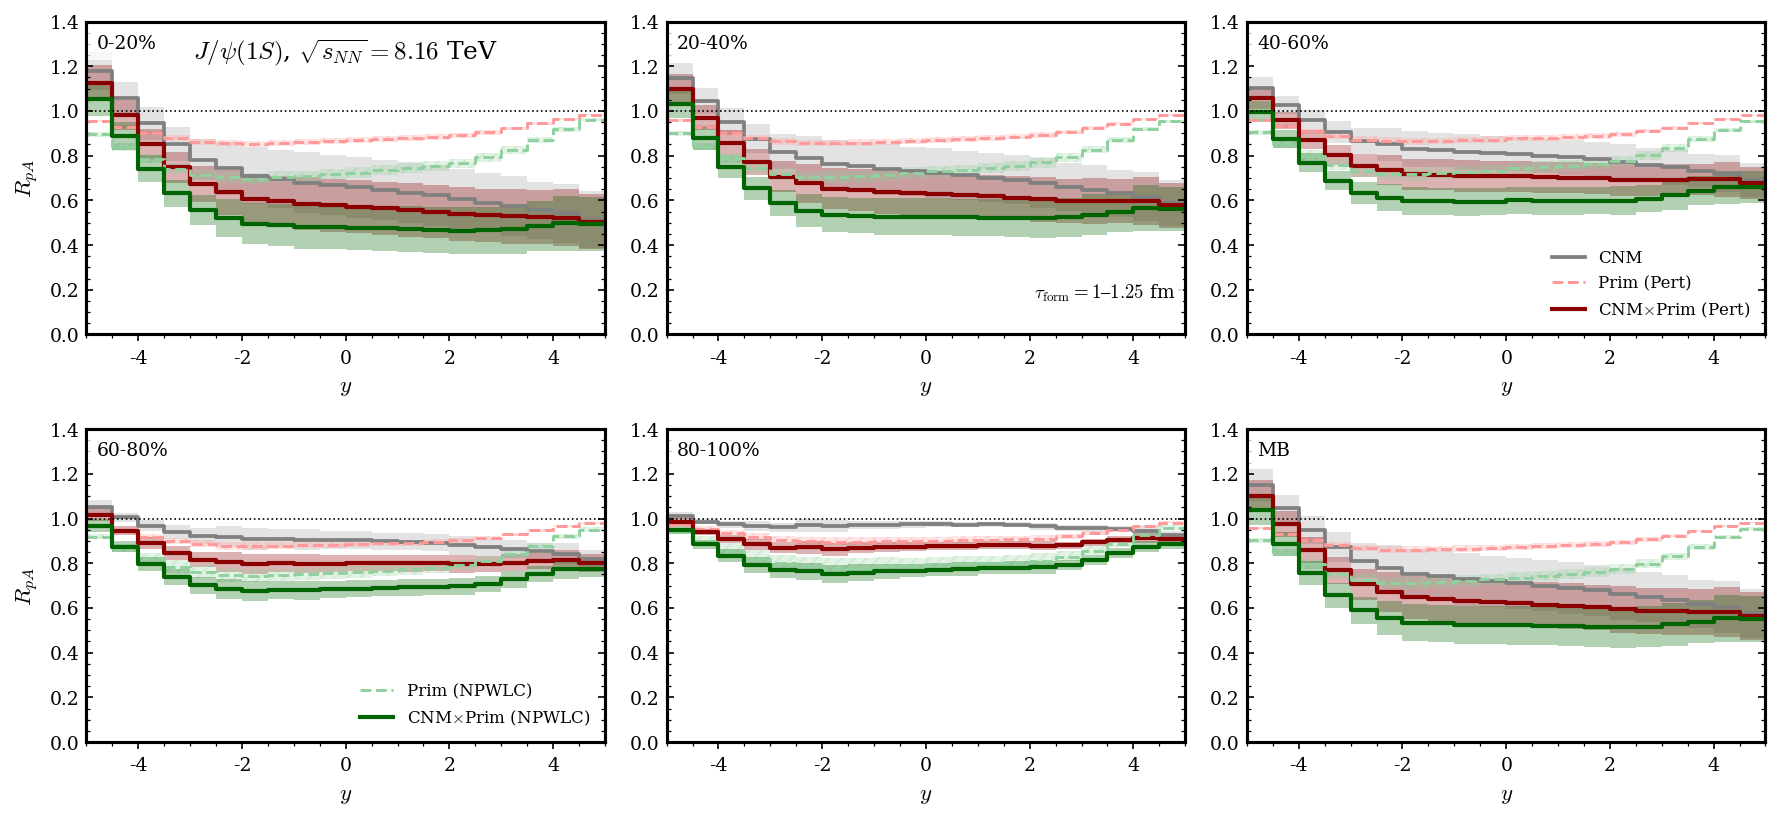

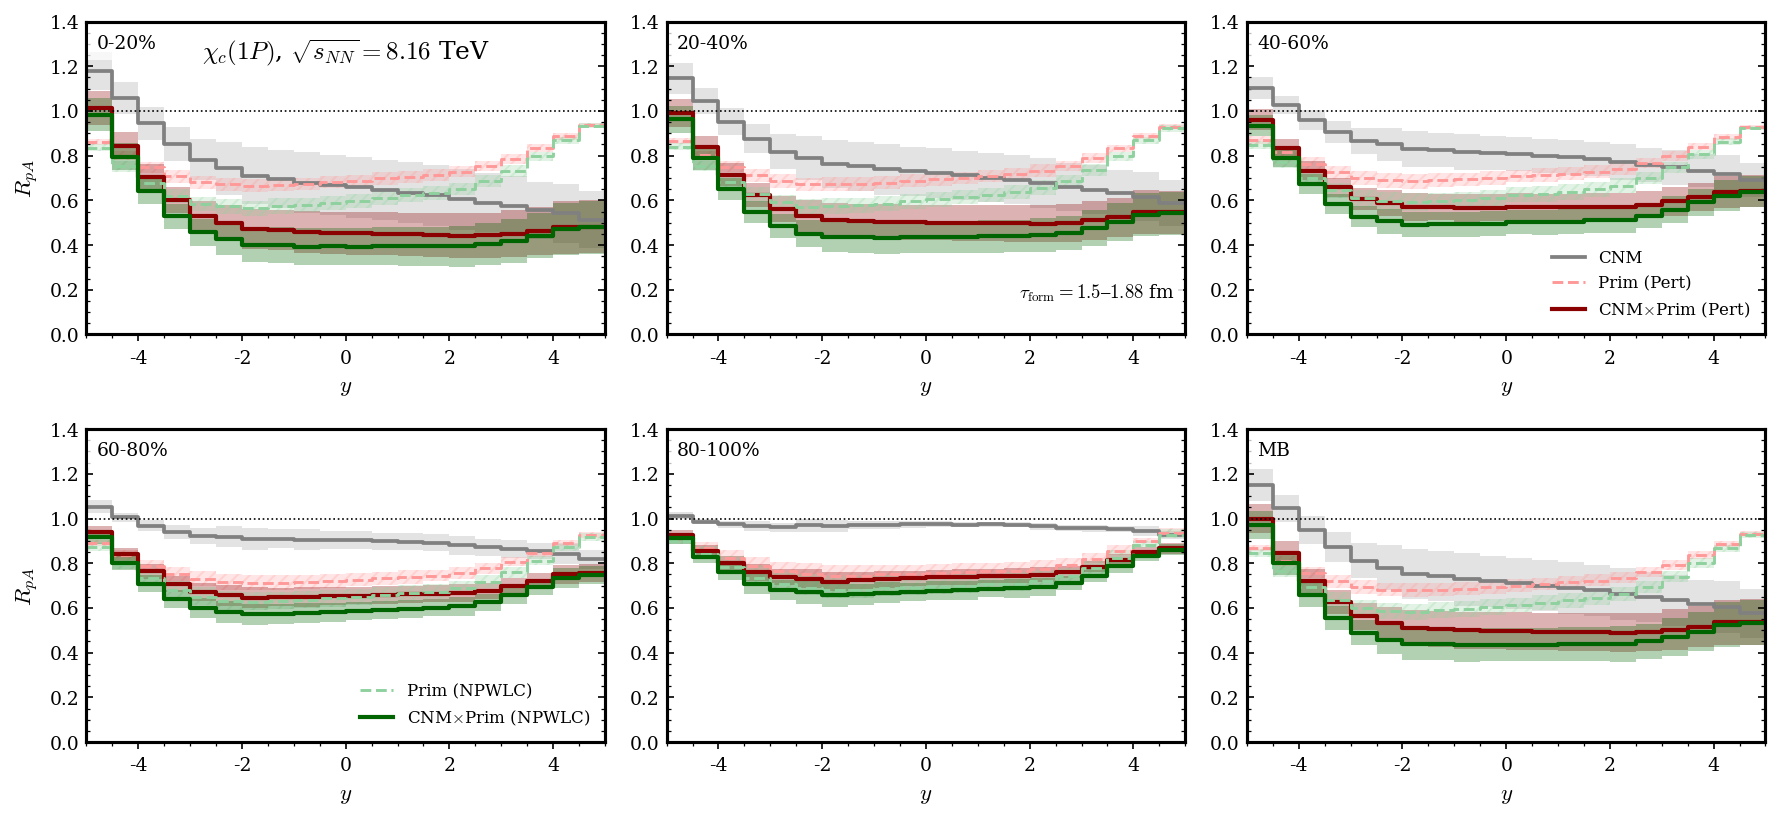

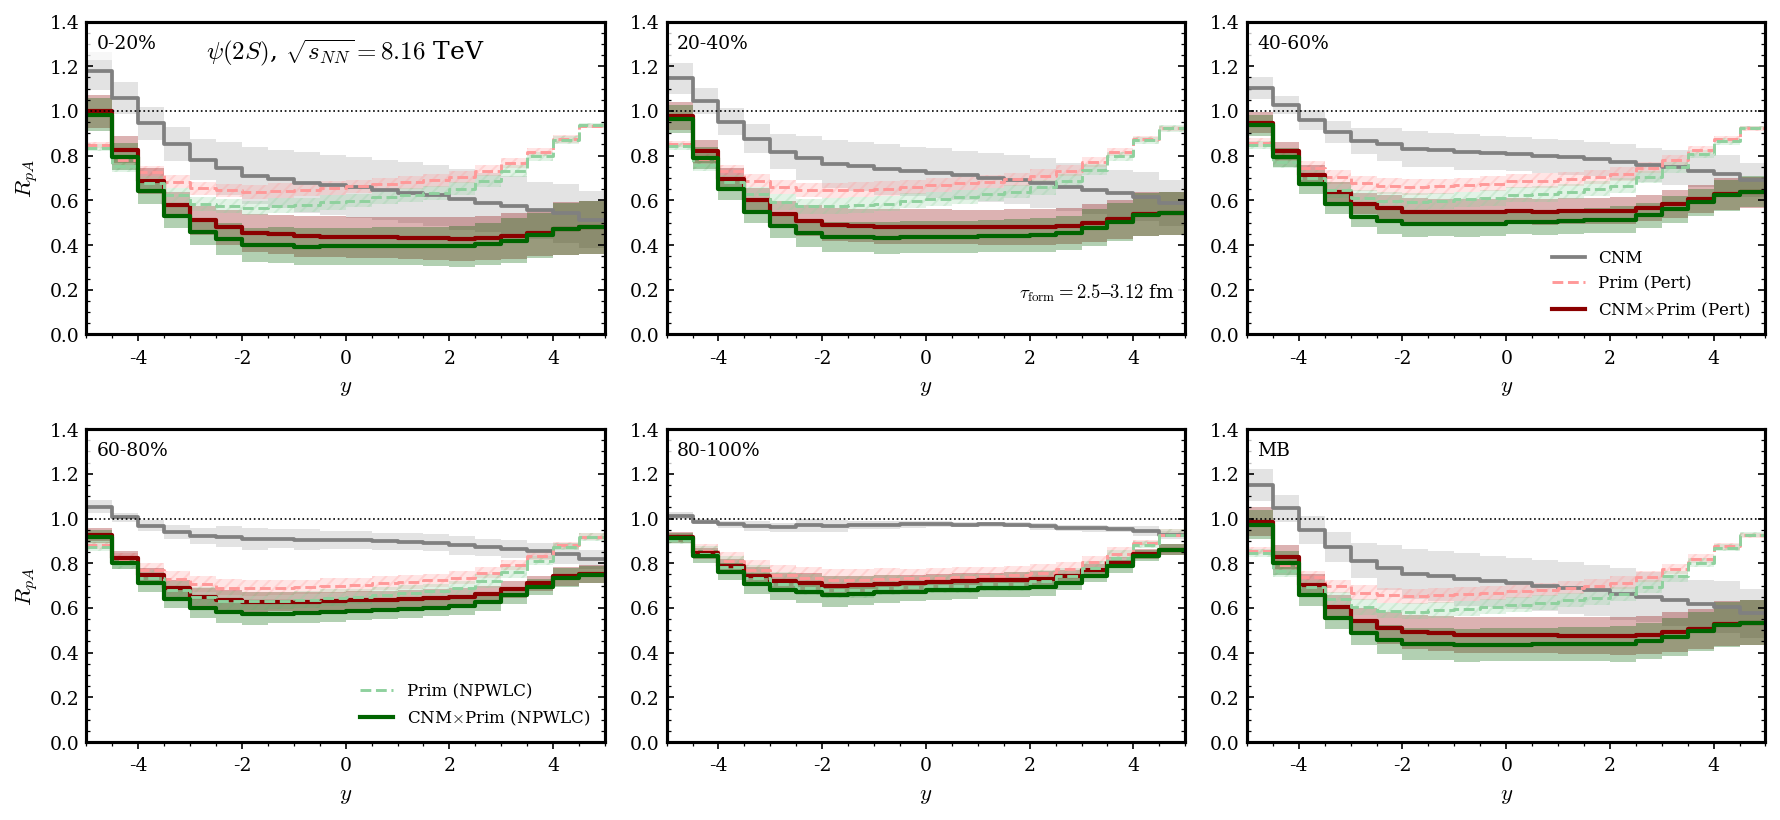

In [ ]:
# ---------- Plot + CSV : R_pA(y) ------------------------------------

# Reuse same switches (can set them once before all three blocks)
SHOW_CNM  = True   # total CNM band
SHOW_PRIM = True   # primordial bands
SHOW_COMB = True   # CNM × primordial

for state in CHARM_STATES:
    n_pan = len(tags_y)
    n_cols = 3
    n_rows = int(np.ceil(n_pan / n_cols))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4.0 * n_cols, 2.8 * n_rows),  # slightly smaller
        dpi=DPI, sharex=False, sharey=False
    )
    axes = np.atleast_1d(axes).ravel()

    handles_all, labels_all = [], []
    csv_rows = []

    for ip, tag in enumerate(tags_y):
        ax = axes[ip]

        # ----- CNM total -----
        Rc_cnm, Rlo_cnm, Rhi_cnm = Rc_cnm_y_all[tag]
        x_edges, y_c  = step_from_centers(y_cent, Rc_cnm)
        _,       y_lo = step_from_centers(y_cent, Rlo_cnm)
        _,       y_hi = step_from_centers(y_cent, Rhi_cnm)

        key = _parse_cent_tag(tag)
        cent_lo, cent_hi, is_mb = None, None, 0
        if key == ("MB",):
            cent_lo, cent_hi, is_mb = 0, 100, 1
        else:
            cent_lo, cent_hi = key

        if SHOW_CNM:
            ln_cnm, = ax.step(
                x_edges, y_c, where="post",
                color=COMB_COLORS["cnm"],
                ls=COMB_LS["cnm"], lw=1.8,
                label=COMB_LABEL["cnm"] if ip == 0 else None
            )
            ax.fill_between(
                x_edges, y_lo, y_hi,
                step="post", color=COMB_COLORS["cnm"],
                alpha=ALPHA_BAND, linewidth=0.0,
            )
            if ip == 0 and COMB_LABEL["cnm"] is not None:
                handles_all.append(ln_cnm)
                labels_all.append(COMB_LABEL["cnm"])

            # CSV for CNM
            for y_min, y_max, y_center, rc, rlo, rhi in zip(
                x_edges[:-1], x_edges[1:], y_cent, Rc_cnm, Rlo_cnm, Rhi_cnm
            ):
                csv_rows.append({
                    "energy": ENERGY,
                    "state": state,
                    "component": "CNM",
                    "prim_model": "",
                    "centrality_lo": cent_lo,
                    "centrality_hi": cent_hi,
                    "is_MB": is_mb,
                    "y_min": y_min,
                    "y_max": y_max,
                    "y_cent": y_center,
                    "R": rc, "R_lo": rlo, "R_hi": rhi,
                })

        # ----- primordial + combined, per model -----
        for model in MODELS:
            # primordial
            if SHOW_PRIM:
                Rc_p, Rlo_p, Rhi_p = _match_prim_y_for_cnm_tag(
                    model=model,
                    state=state,
                    cnm_tag=tag,
                    y_cent_cnm=y_cent,
                )
                _, y_p_c  = step_from_centers(y_cent, Rc_p)
                _, y_p_lo = step_from_centers(y_cent, Rlo_p)
                _, y_p_hi = step_from_centers(y_cent, Rhi_p)

                ln_p, = ax.step(
                    x_edges, y_p_c, where="post",
                    color=COMB_COLORS[(model, "prim")],
                    ls=COMB_LS[(model, "prim")], lw=1.4,
                    label=COMB_LABEL[(model, "prim")] if ip == 0 else None,
                )
                ax.fill_between(
                    x_edges, y_p_lo, y_p_hi,
                    step="post", color=COMB_COLORS[(model, "prim")],
                    hatch='////',
                    alpha=0.25, linewidth=0.0,
                )
                if ip == 0:
                    handles_all.append(ln_p)
                    labels_all.append(COMB_LABEL[(model, "prim")])

                # CSV for primordial
                for y_min, y_max, y_center, rc, rlo, rhi in zip(
                    x_edges[:-1], x_edges[1:], y_cent, Rc_p, Rlo_p, Rhi_p
                ):
                    csv_rows.append({
                        "energy": ENERGY,
                        "state": state,
                        "component": "primordial",
                        "prim_model": model,
                        "centrality_lo": cent_lo,
                        "centrality_hi": cent_hi,
                        "is_MB": is_mb,
                        "y_min": y_min,
                        "y_max": y_max,
                        "y_cent": y_center,
                        "R": rc, "R_lo": rlo, "R_hi": rhi,
                    })

            # combined CNM×prim
            if SHOW_COMB:
                Rc_cb, Rlo_cb, Rhi_cb, y_cent_cb = combined_y[state][model][tag]
                x_edges_cb, y_cb_c  = step_from_centers(y_cent_cb, Rc_cb)
                _,           y_cb_lo = step_from_centers(y_cent_cb, Rlo_cb)
                _,           y_cb_hi = step_from_centers(y_cent_cb, Rhi_cb)

                ln_cb, = ax.step(
                    x_edges_cb, y_cb_c, where="post",
                    color=COMB_COLORS[(model, "comb")],
                    ls=COMB_LS[(model, "comb")], lw=2.0,
                    label=COMB_LABEL[(model, "comb")] if ip == 0 else None,
                )
                ax.fill_between(
                    x_edges_cb, y_cb_lo, y_cb_hi,
                    step="post", color=COMB_COLORS[(model, "comb")],
                    alpha=0.30, linewidth=0.0,
                )
                if ip == 0:
                    handles_all.append(ln_cb)
                    labels_all.append(COMB_LABEL[(model, "comb")])

                # CSV for combined
                for y_min, y_max, y_center, rc, rlo, rhi in zip(
                    x_edges_cb[:-1], x_edges_cb[1:], y_cent_cb, Rc_cb, Rlo_cb, Rhi_cb
                ):
                    csv_rows.append({
                        "energy": ENERGY,
                        "state": state,
                        "component": "CNM_x_prim",
                        "prim_model": model,
                        "centrality_lo": cent_lo,
                        "centrality_hi": cent_hi,
                        "is_MB": is_mb,
                        "y_min": y_min,
                        "y_max": y_max,
                        "y_cent": y_center,
                        "R": rc, "R_lo": rlo, "R_hi": rhi,
                    })

        # ----- axis cosmetics -----
        ax.axhline(1.0, color="k", ls=":", lw=0.8)
        ax.set_xlim(-5, 5)
        ax.set_ylim(0.0, 1.35)
        ax.set_xlabel(r"$y$", fontsize=11)
        if ip % n_cols == 0:
            ax.set_ylabel(r"$R_{pA}$", fontsize=11)

        # ticks: Y in (both sides), X out (bottom only), smaller labels
        ax.minorticks_on()
        ax.tick_params(axis='y', which='both', direction='in', right=True)
        ax.tick_params(axis='x', which='both', direction='out', top=False, bottom=True)
        ax.set_yticks(np.arange(0.0, 1.41, 0.2))
        ax.tick_params(axis='both', which='major', labelsize=9)
        ax.tick_params(axis='both', which='minor', labelsize=9)
        ax.grid(False)

        # centrality tag label
        ax.text(
            0.02, 0.96, tag,
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=9,
            bbox=dict(facecolor="white", alpha=0.75, edgecolor="none")
        )

    # hide unused axes
    for k in range(n_pan, len(axes)):
        axes[k].set_visible(False)

    # ---------- legends split across two panels ----------
    if handles_all:
        uniq = {}
        for h, l in zip(handles_all, labels_all):
            uniq[l] = h
        legend_handles = list(uniq.values())
        legend_labels  = list(uniq.keys())

        mid = (len(legend_handles) + 1) // 2
        h1, l1 = legend_handles[:mid], legend_labels[:mid]
        h2, l2 = legend_handles[mid:], legend_labels[mid:]

        # Choose panels for legends: 3rd and 4th if visible, else fall back
        idx_leg1 = 2 if len(axes) > 2 and axes[2].get_visible() else 0
        idx_leg2 = 3 if len(axes) > 3 and axes[3].get_visible() else idx_leg1

        axes[idx_leg1].legend(
            h1, l1,
            loc="lower right", frameon=False, fontsize=8,
        )
        if h2:
            axes[idx_leg2].legend(
                h2, l2,
                loc="lower right", frameon=False, fontsize=8,
            )

    # ----- in-panel notes: state, energy, tau_form -----
    tau_lo, tau_hi = TAUFORM[state]

    # State + energy in first panel
    note_line1 = rf"{CHARM_STATE_LABELS[state]}, $\sqrt{{s_{{NN}}}}={float(ENERGY):.2f}$ TeV"
    axes[0].text(
        0.50, 0.95, note_line1,
        transform=axes[0].transAxes,
        ha="center", va="top",
        fontsize=12,
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"),
    )

    # tau_form in second panel (or first if only one)
    if len(axes) > 1 and axes[1].get_visible():
        ax2 = axes[1]
    else:
        ax2 = axes[0]

    note_tau = rf"$\tau_{{\rm form}}={tau_lo:.3g}\text{{–}}{tau_hi:.3g}$ fm"
    ax2.text(
        0.98, 0.10, note_tau,
        transform=ax2.transAxes,
        ha="right", va="bottom",
        fontsize=9,
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"),
    )

    fig.tight_layout()

    if SAVE_PDF:
        fig.savefig(
            OUTDIR_CNM / f"RpA_CNM_prim_combined_vs_y_{state}_{ENERGY.replace('.','p')}TeV.pdf",
            bbox_inches="tight",
        )

    if SAVE_CSV and csv_rows:
        df_out = pd.DataFrame(csv_rows)
        df_out.to_csv(
            OUTDIR_CNM / f"RpA_CNM_prim_combined_vs_y_{state}_{ENERGY.replace('.','p')}TeV.csv",
            index=False,
        )

## $R_{pA}$ vs Transverse Momentum ($p_T$)

In [ ]:
# =====================================================================
# 6. CNM × Prim: R_pA(pT) in 3 rapidity windows
# =====================================================================

combined_pt = {st: {} for st in CHARM_STATES}
pT_edges = np.array(DEFAULT_P_EDGES, float)
pT_cent = pT_edges[:-1] + 0.5 * np.diff(pT_edges)

for (y0, y1, yname) in DEFAULT_Y_WINDOWS:
    if yname not in cnm_pt_all:
        continue

    cnm_pt_block = cnm_pt_all[yname]

    # Map CNM y-window → primordial y-window key ('forward', 'central', 'backward')
    prim_key = _cnm_ywindow_to_prim_key(y0, y1, yname)

    for state in CHARM_STATES:
        # keep CNM label (pretty text) as the key in combined_pt
        combined_pt[state].setdefault(yname, {m: {} for m in MODELS})

        for model in MODELS:
            for tag in cnm_pt_block["cnm"].keys():
                # CNM band in this y-window/tag
                Rc_cnm, Rlo_cnm, Rhi_cnm = cnm_pt_block["cnm"][tag]

                # Primordial band interpolated to CNM pT grid
                Rc_prim, Rlo_prim, Rhi_prim = _match_prim_pT_for_cnm_tag(
                    yname=prim_key,      # <-- use primordial key here
                    model=model,
                    state=state,
                    cnm_tag=tag,
                    pT_cent_cnm=pT_cent,
                )

                # Combine
                Rc_cb, Rlo_cb, Rhi_cb = _combine_cnm_and_prim_1d(
                    Rc_cnm, Rlo_cnm, Rhi_cnm,
                    Rc_prim, Rlo_prim, Rhi_prim,
                )
                combined_pt[state][yname][model][tag] = (
                    Rc_cb, Rlo_cb, Rhi_cb, pT_cent.copy()
                )


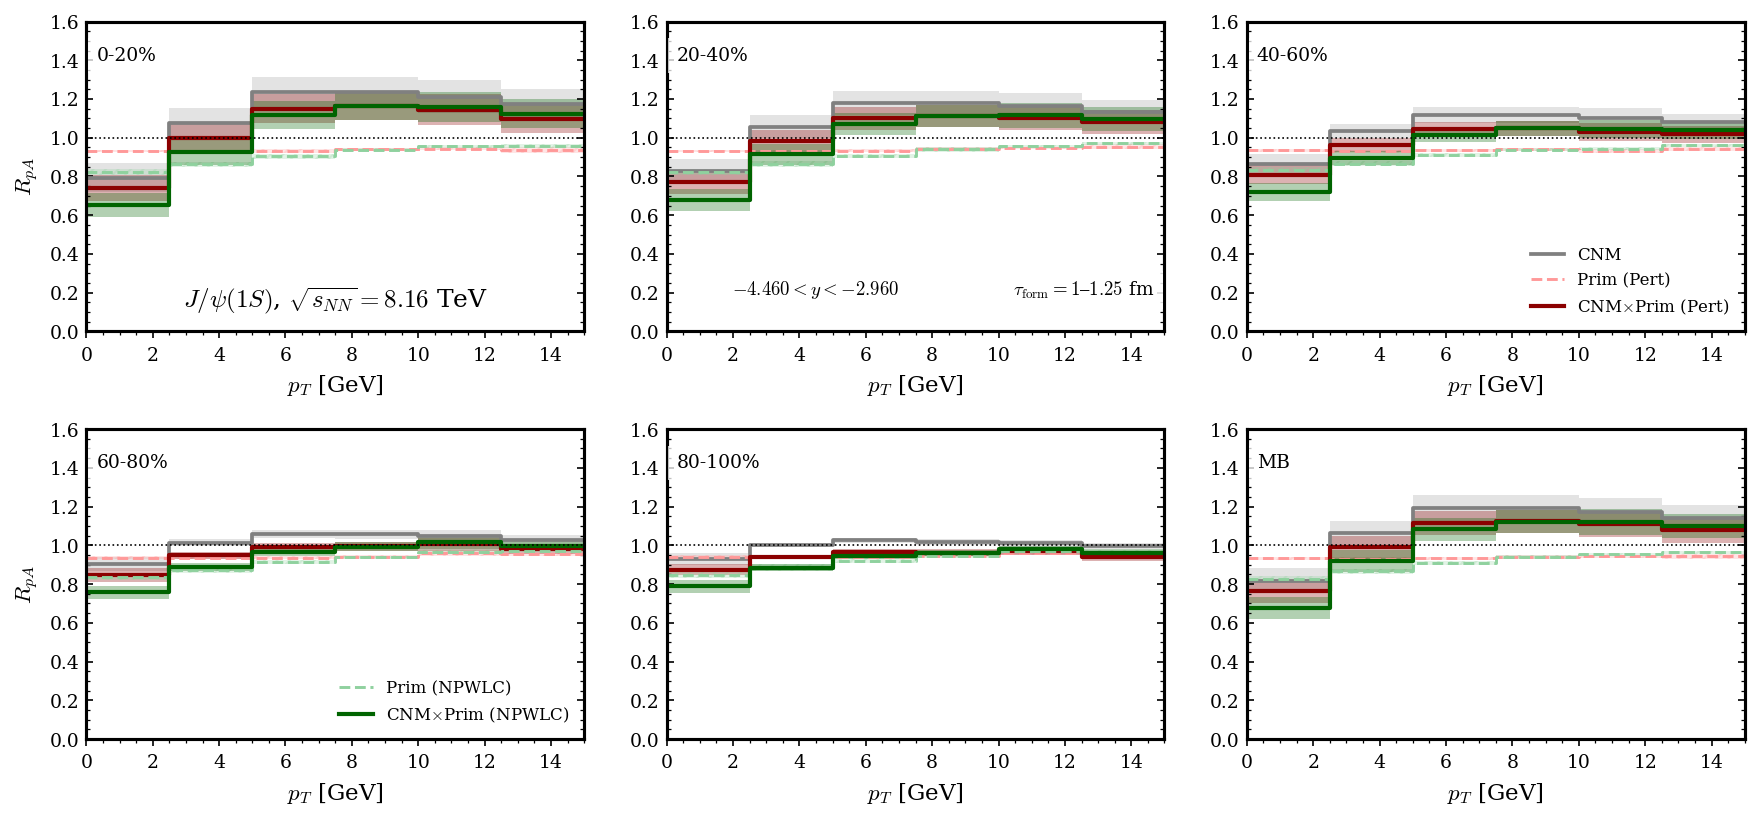

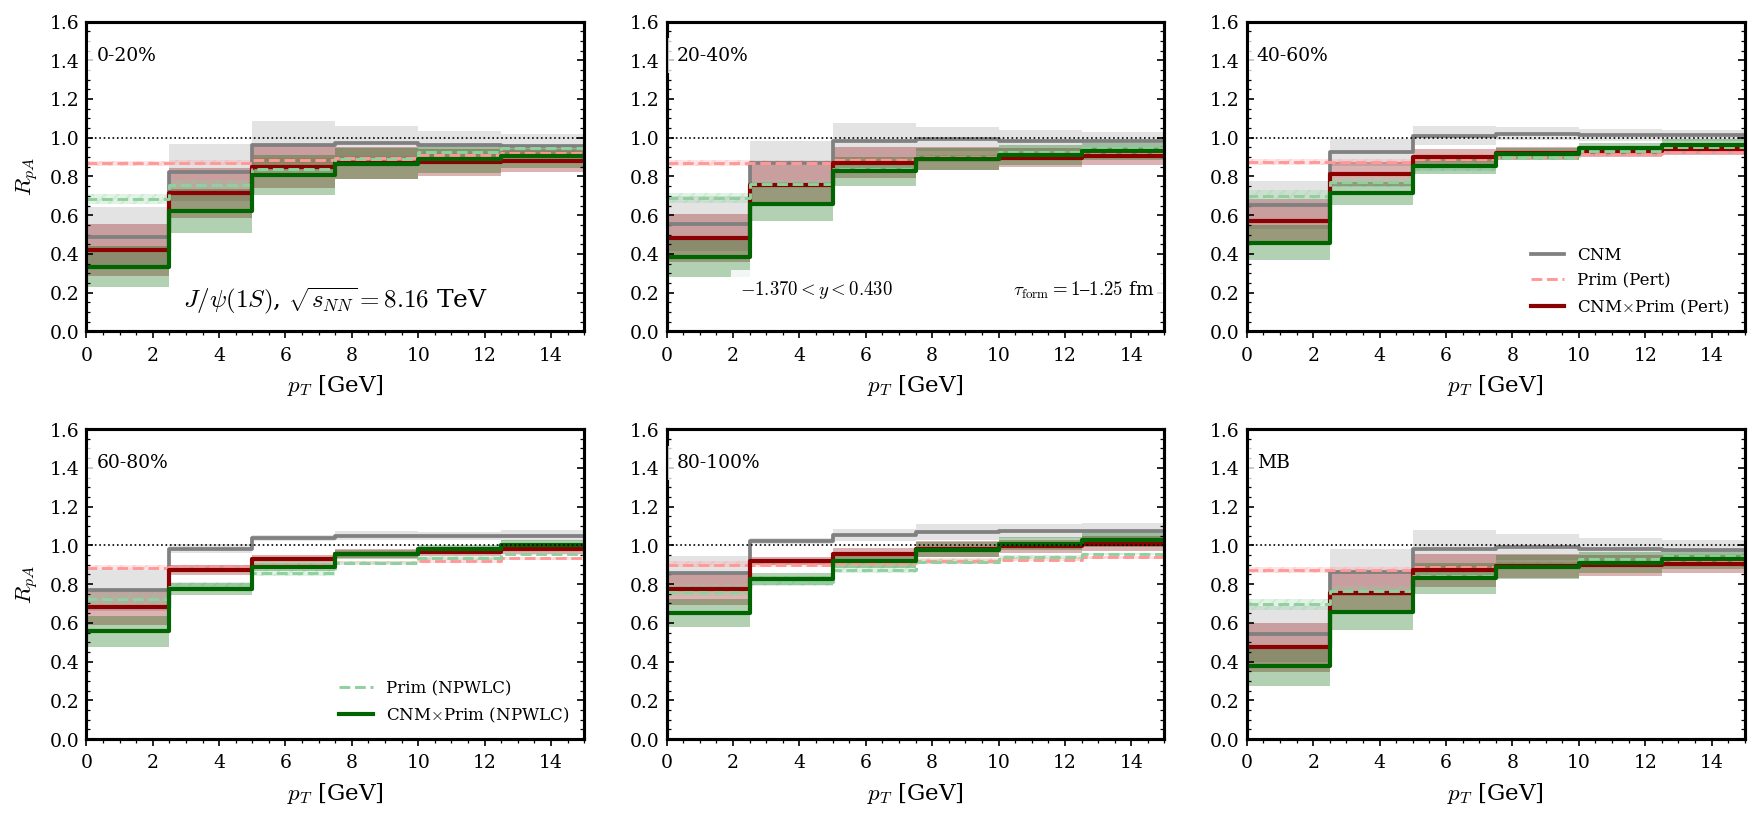

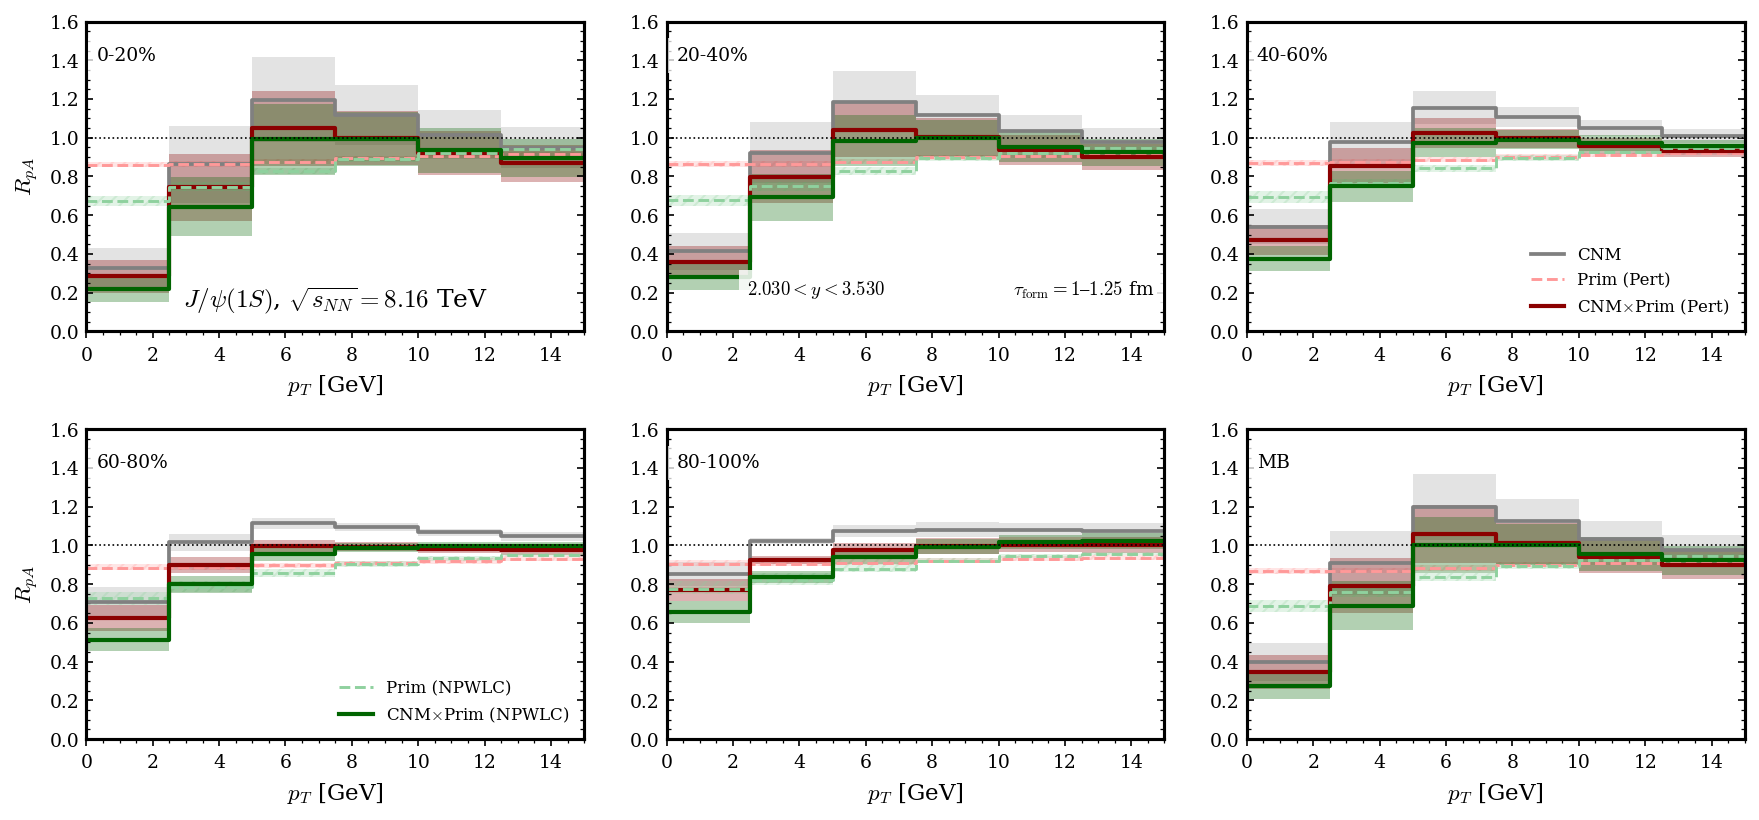

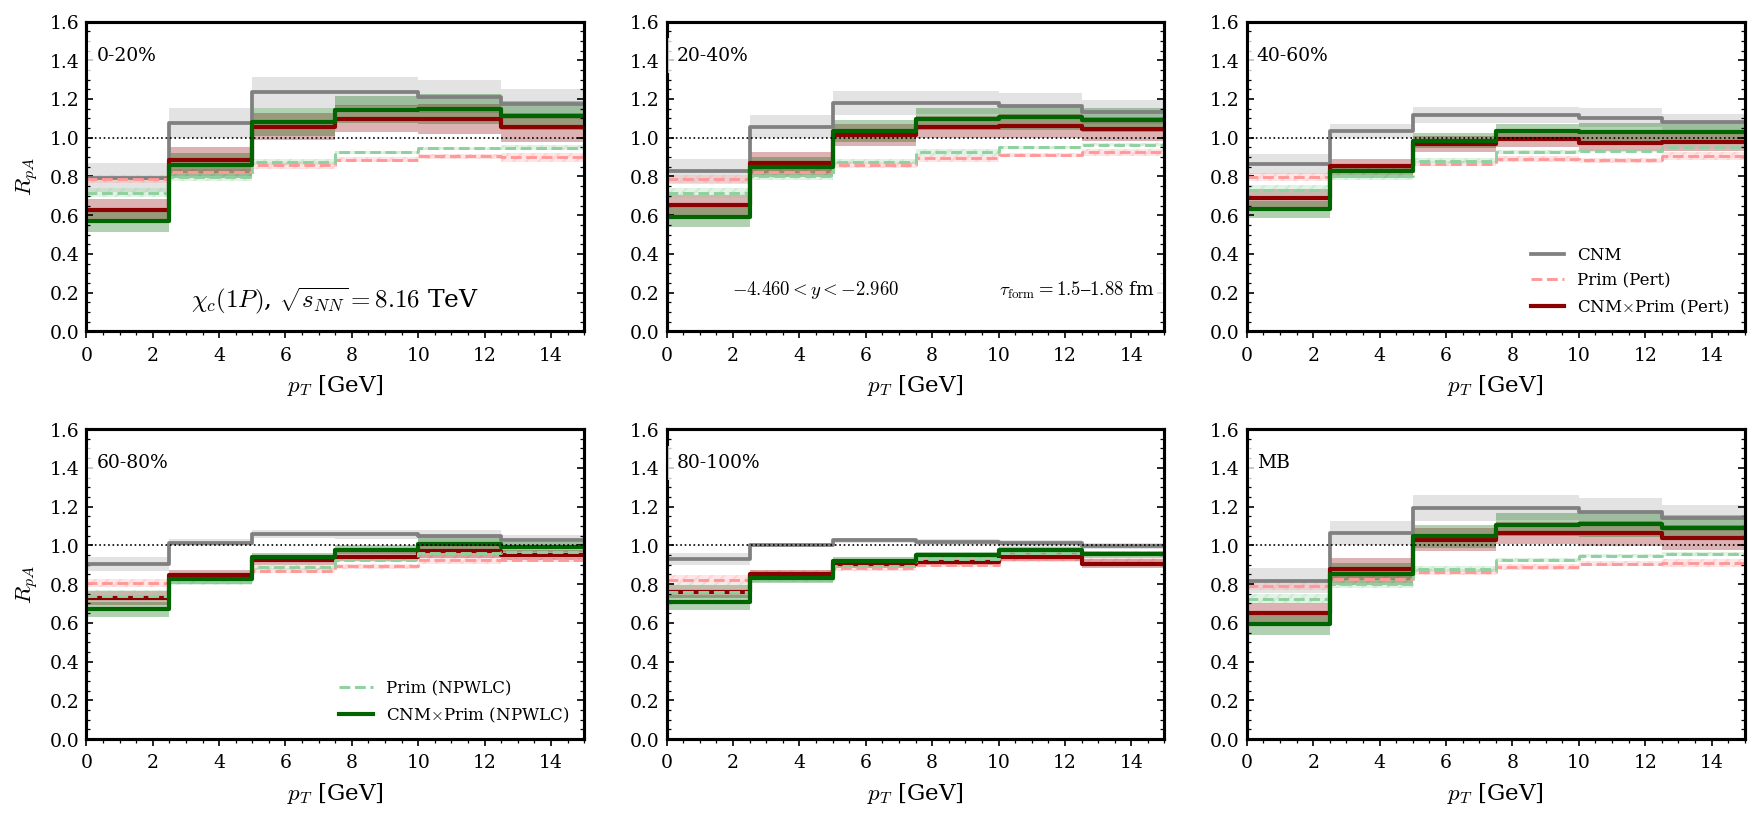

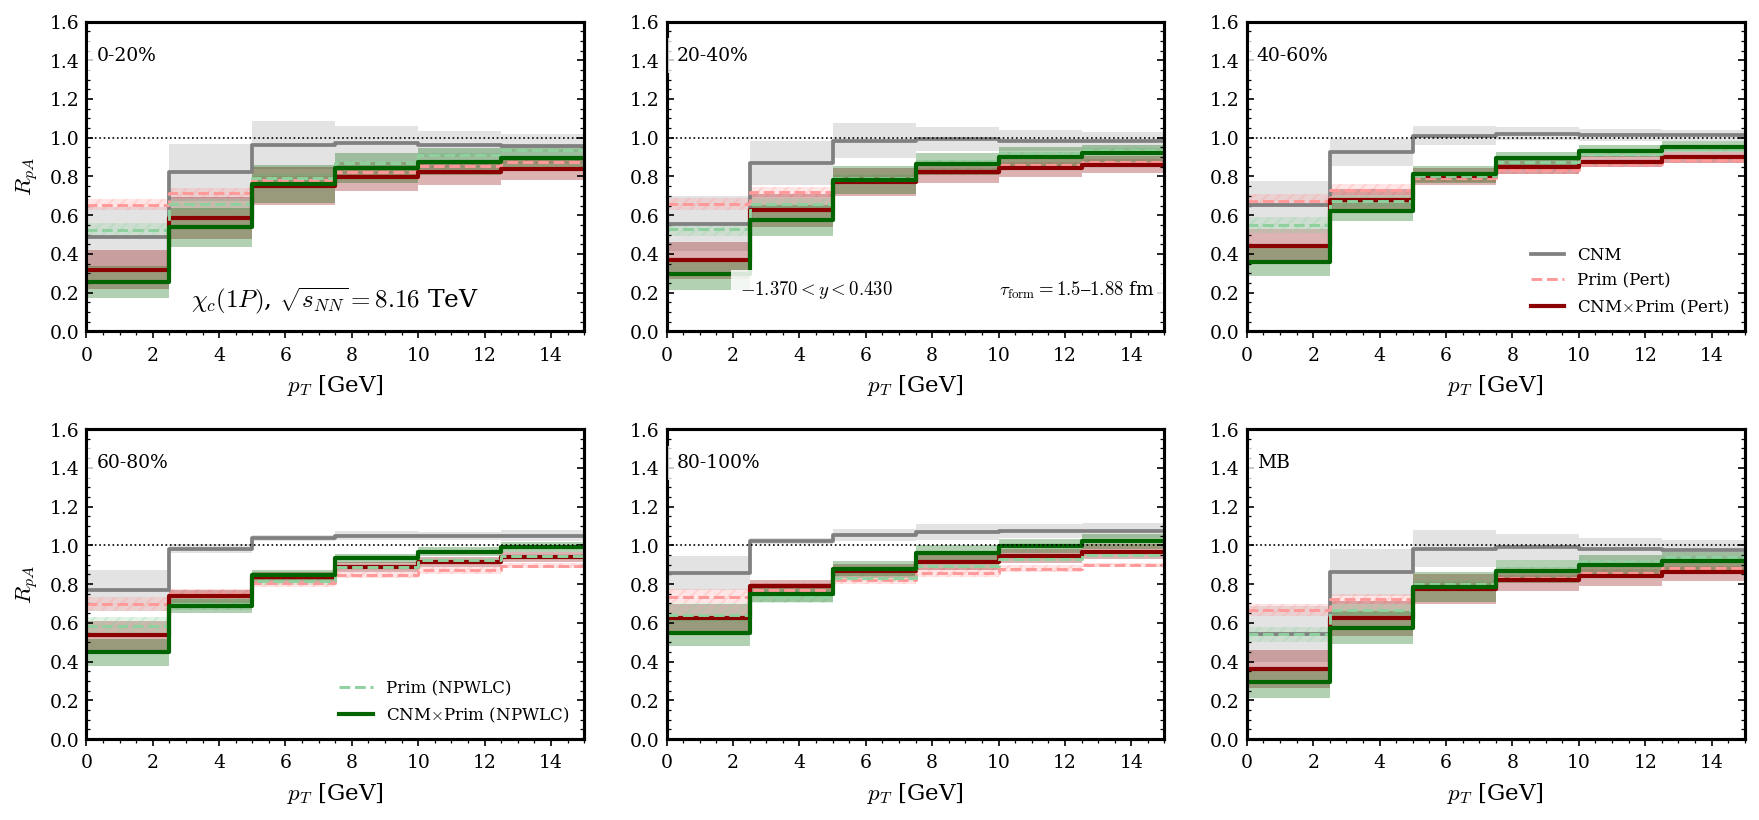

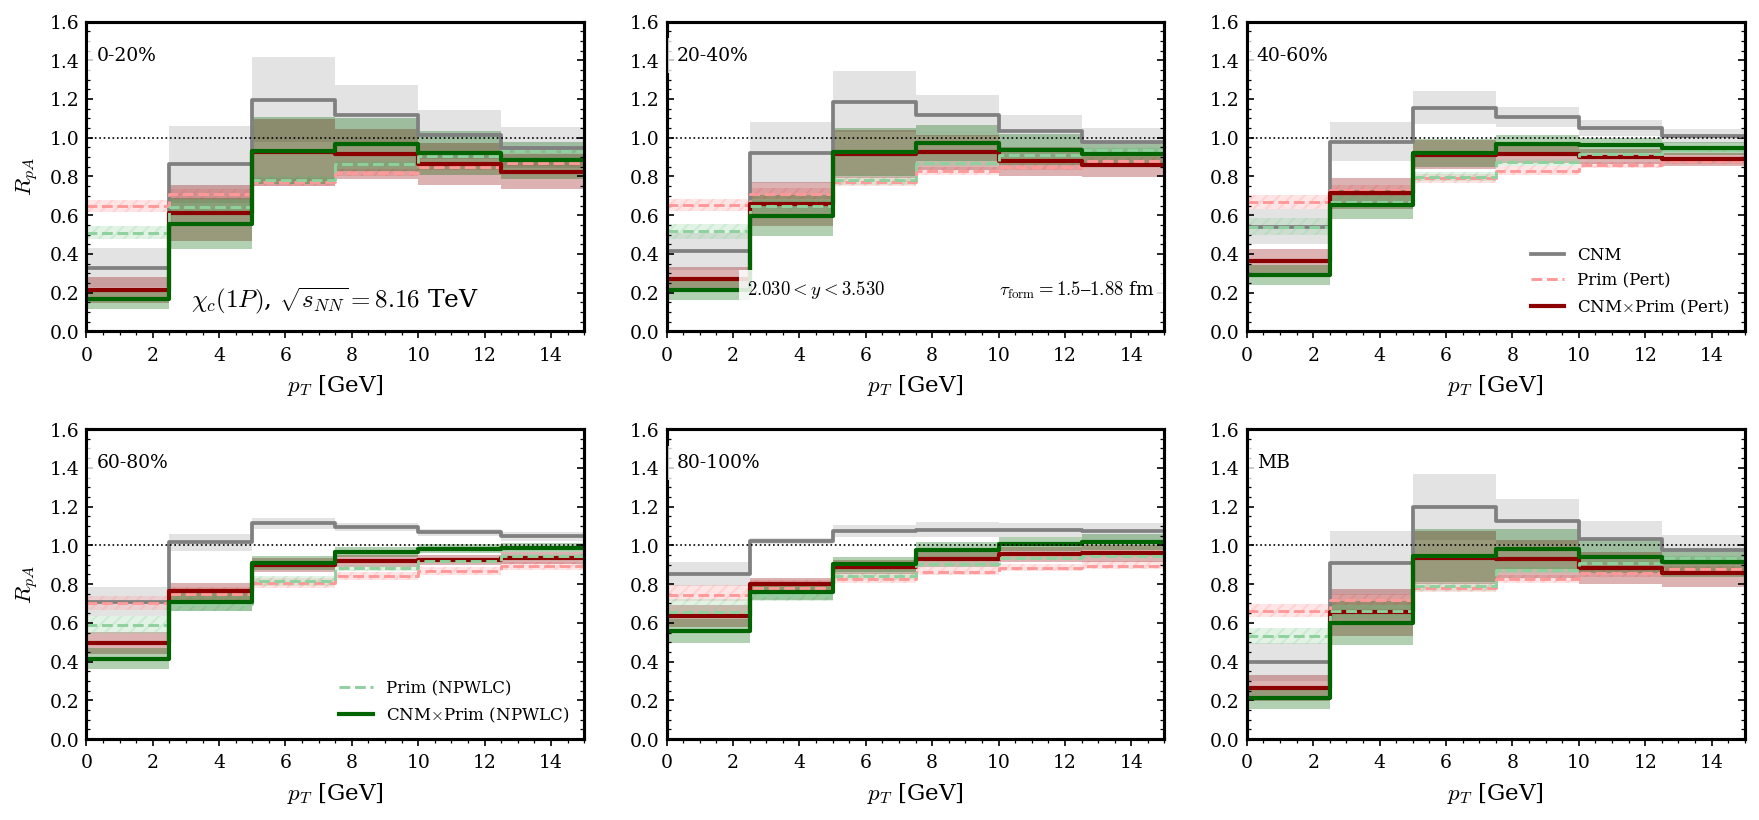

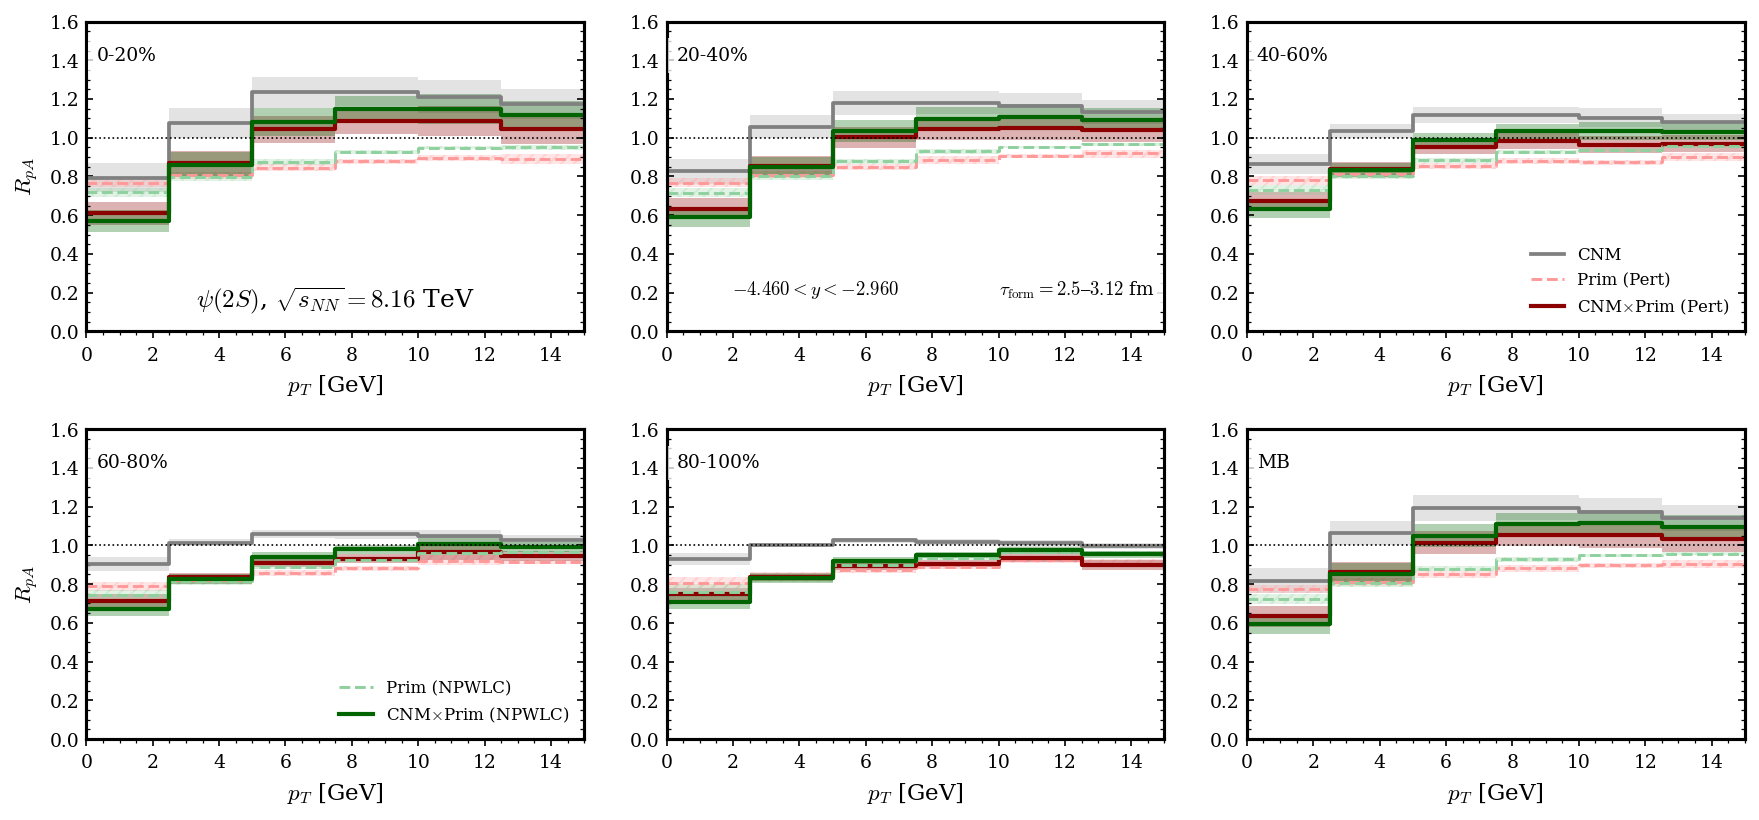

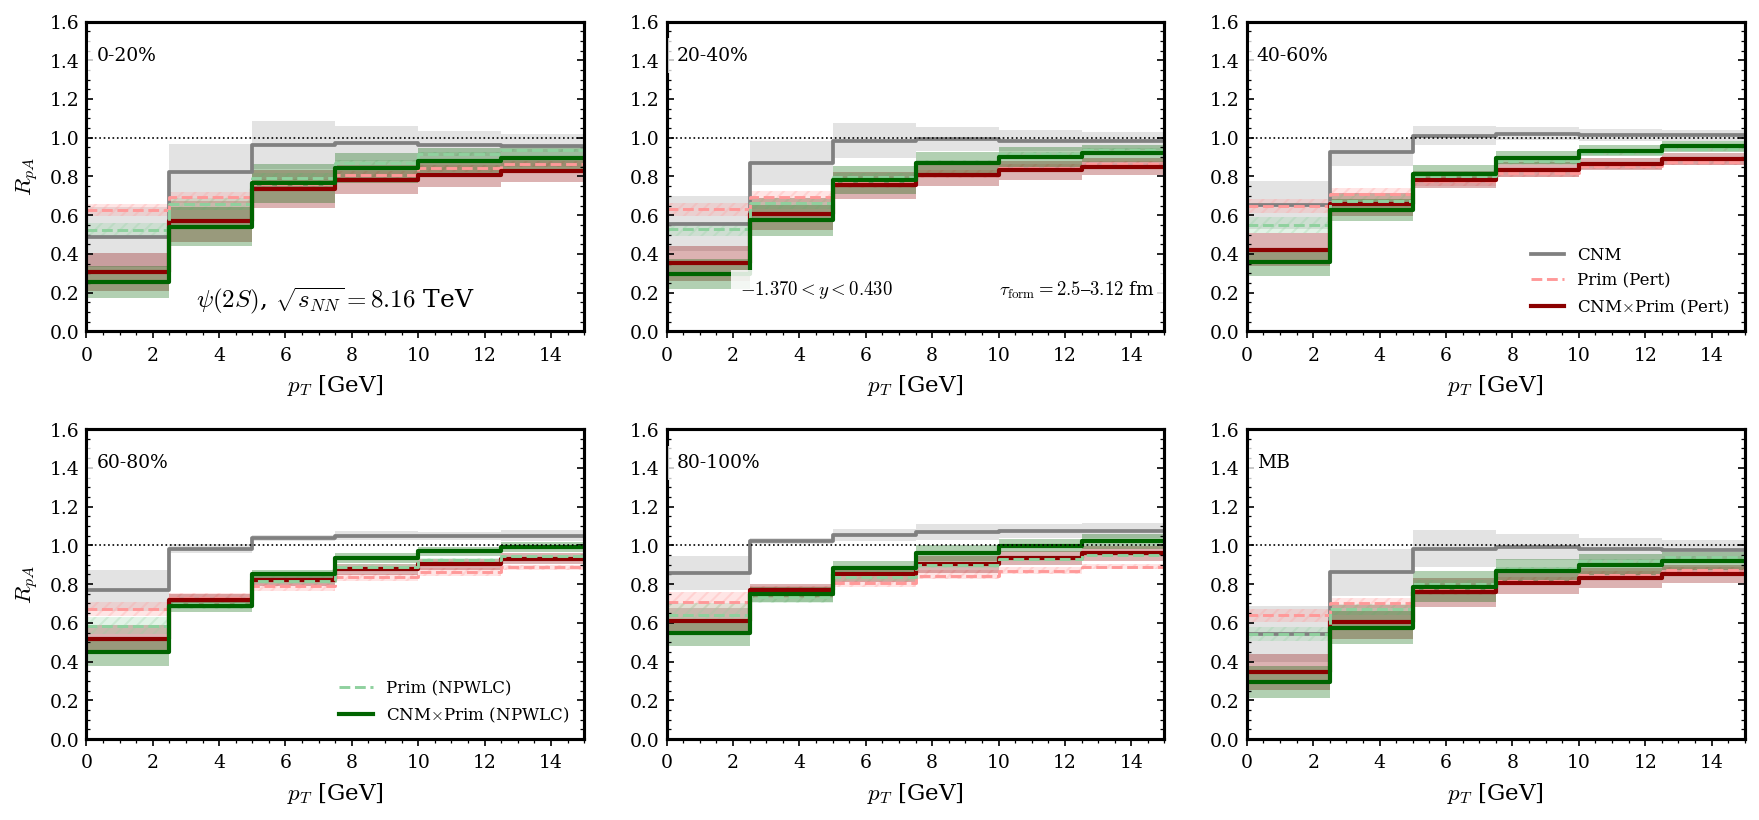

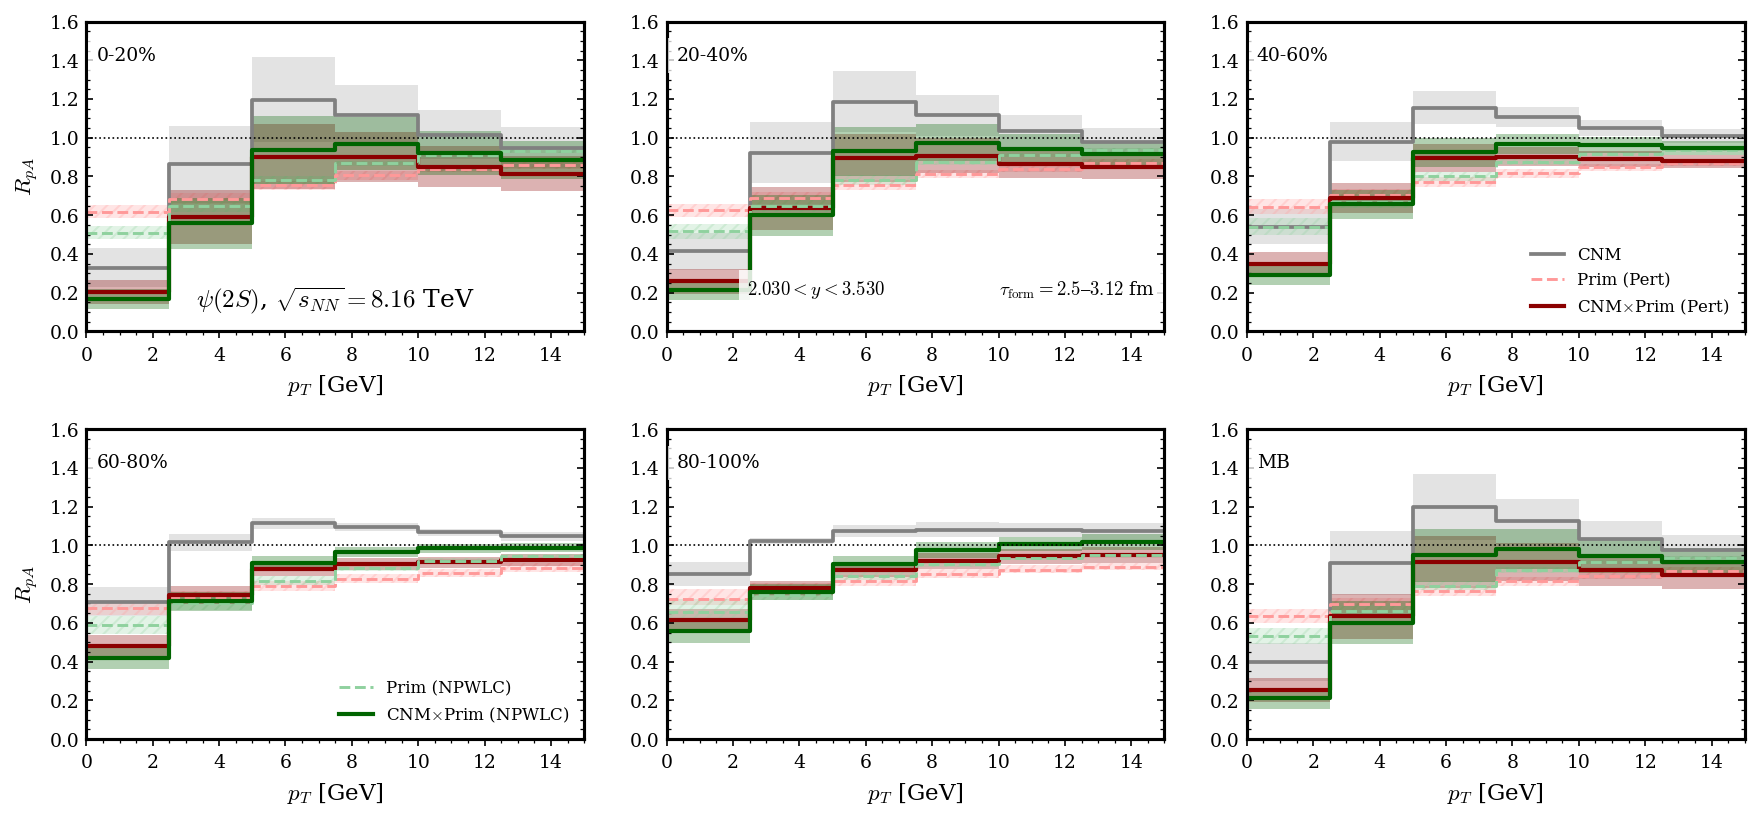

In [ ]:
# ---------- Plot + CSV: R_pA(pT) -------------------------------------

# Minimal switches to show/hide components (like centrality block)
SHOW_CNM  = True   # total CNM band
SHOW_PRIM = True   # primordial bands
SHOW_COMB = True   # CNM × primordial

for state in CHARM_STATES:
    for (y0, y1, yname) in DEFAULT_Y_WINDOWS:
        if yname not in cnm_pt_all:
            continue

        cnm_pt_block = cnm_pt_all[yname]
        tags_pt = list(cnm_pt_block["cnm"].keys())

        # Map CNM label to primordial key
        prim_key = _cnm_ywindow_to_prim_key(y0, y1, yname)

        n_pan = len(tags_pt)
        n_cols = 3
        n_rows = int(np.ceil(n_pan / n_cols))

        fig, axes = plt.subplots(
            n_rows, n_cols,
            figsize=(4.0 * n_cols, 2.8 * n_rows),  # slightly smaller labels-friendly size
            dpi=DPI, sharex=False, sharey=False
        )
        axes = np.atleast_1d(axes).ravel()

        handles_all, labels_all = [], []
        csv_rows = []

        for ip, tag in enumerate(tags_pt):
            ax = axes[ip]

            # ---------------- CNM alone ----------------
            Rc_cnm, Rlo_cnm, Rhi_cnm = cnm_pt_block["cnm"][tag]
            x_edges, y_c  = step_from_centers(pT_cent, Rc_cnm)
            _,       y_lo = step_from_centers(pT_cent, Rlo_cnm)
            _,       y_hi = step_from_centers(pT_cent, Rhi_cnm)

            key = _parse_cent_tag(tag)
            cent_lo, cent_hi, is_mb = None, None, 0
            if key == ("MB",):
                cent_lo, cent_hi, is_mb = 0, 100, 1
            else:
                cent_lo, cent_hi = key

            if SHOW_CNM:
                ln_cnm, = ax.step(
                    x_edges, y_c,
                    where="post",
                    color=COMB_COLORS["cnm"],
                    ls=COMB_LS["cnm"], lw=1.8,
                    label=COMB_LABEL["cnm"] if ip == 0 else None,
                )
                ax.fill_between(
                    x_edges, y_lo, y_hi,
                    step="post", color=COMB_COLORS["cnm"],
                    alpha=ALPHA_BAND, linewidth=0.0,
                )
                if ip == 0:
                    handles_all.append(ln_cnm)
                    labels_all.append(COMB_LABEL["cnm"])

                # CSV for CNM
                for pt_min, pt_max, pt_c, rc, rlo, rhi in zip(
                    x_edges[:-1], x_edges[1:], pT_cent, Rc_cnm, Rlo_cnm, Rhi_cnm
                ):
                    csv_rows.append({
                        "energy": ENERGY,
                        "state": state,
                        "component": "CNM",
                        "prim_model": "",
                        "y_window": yname,
                        "centrality_lo": cent_lo,
                        "centrality_hi": cent_hi,
                        "is_MB": is_mb,
                        "pT_min": pt_min,
                        "pT_max": pt_max,
                        "pT_cent": pt_c,
                        "R": rc, "R_lo": rlo, "R_hi": rhi,
                    })

            # ------------- primordial + combined -------------
            for model in MODELS:
                # primordial: only if we want to show/save it
                if SHOW_PRIM:
                    Rc_p, Rlo_p, Rhi_p = _match_prim_pT_for_cnm_tag(
                        yname=prim_key,
                        model=model,
                        state=state,
                        cnm_tag=tag,
                        pT_cent_cnm=pT_cent,
                    )
                    _, y_p_c  = step_from_centers(pT_cent, Rc_p)
                    _, y_p_lo = step_from_centers(pT_cent, Rlo_p)
                    _, y_p_hi = step_from_centers(pT_cent, Rhi_p)

                    ln_p, = ax.step(
                        x_edges, y_p_c, where="post",
                        color=COMB_COLORS[(model, "prim")],
                        ls=COMB_LS[(model, "prim")], lw=1.4,
                        label=COMB_LABEL[(model, "prim")] if ip == 0 else None,
                    )
                    ax.fill_between(
                        x_edges, y_p_lo, y_p_hi,
                        step="post", color=COMB_COLORS[(model, "prim")],
                        alpha=0.25, linewidth=0.0,
                        hatch='////',
                    )
                    if ip == 0:
                        handles_all.append(ln_p)
                        labels_all.append(COMB_LABEL[(model, "prim")])

                    # CSV primordial
                    for pt_min, pt_max, pt_c, rc, rlo, rhi in zip(
                        x_edges[:-1], x_edges[1:], pT_cent, Rc_p, Rlo_p, Rhi_p
                    ):
                        csv_rows.append({
                            "energy": ENERGY,
                            "state": state,
                            "component": "primordial",
                            "prim_model": model,
                            "y_window": yname,
                            "centrality_lo": cent_lo,
                            "centrality_hi": cent_hi,
                            "is_MB": is_mb,
                            "pT_min": pt_min,
                            "pT_max": pt_max,
                            "pT_cent": pt_c,
                            "R": rc, "R_lo": rlo, "R_hi": rhi,
                        })

                # combined: always available from combined_pt
                if SHOW_COMB:
                    Rc_cb, Rlo_cb, Rhi_cb, pT_cent_cb = combined_pt[state][yname][model][tag]
                    x_edges_cb, y_cb_c  = step_from_centers(pT_cent_cb, Rc_cb)
                    _,           y_cb_lo = step_from_centers(pT_cent_cb, Rlo_cb)
                    _,           y_cb_hi = step_from_centers(pT_cent_cb, Rhi_cb)

                    ln_cb, = ax.step(
                        x_edges_cb, y_cb_c, where="post",
                        color=COMB_COLORS[(model, "comb")],
                        ls=COMB_LS[(model, "comb")], lw=2.0,
                        label=COMB_LABEL[(model, "comb")] if ip == 0 else None,
                    )
                    ax.fill_between(
                        x_edges_cb, y_cb_lo, y_cb_hi,
                        step="post", color=COMB_COLORS[(model, "comb")],
                        alpha=0.30, linewidth=0.0,
                    )
                    if ip == 0:
                        handles_all.append(ln_cb)
                        labels_all.append(COMB_LABEL[(model, "comb")])

                    # CSV combined
                    for pt_min, pt_max, pt_c, rc, rlo, rhi in zip(
                        x_edges_cb[:-1], x_edges_cb[1:], pT_cent_cb, Rc_cb, Rlo_cb, Rhi_cb
                    ):
                        csv_rows.append({
                            "energy": ENERGY,
                            "state": state,
                            "component": "CNM_x_prim",
                            "prim_model": model,
                            "y_window": yname,
                            "centrality_lo": cent_lo,
                            "centrality_hi": cent_hi,
                            "is_MB": is_mb,
                            "pT_min": pt_min,
                            "pT_max": pt_max,
                            "pT_cent": pt_c,
                            "R": rc, "R_lo": rlo, "R_hi": rhi,
                        })

            # --------- axis cosmetics (no grid) ---------
            ax.axhline(1.0, color="k", ls=":", lw=0.8)
            ax.set_xlim(pT_edges[0], pT_edges[-1])
            ax.set_ylim(0.0, 1.45)
            ax.set_xlabel(r"$p_T$ [GeV]", fontsize=11)
            if ip % n_cols == 0:
                ax.set_ylabel(r"$R_{pA}$", fontsize=11)

            # ticks: Y in, both sides; X out, bottom only
            ax.minorticks_on()
            ax.tick_params(axis='y', which='both', direction='in', right=True)
            ax.tick_params(axis='x', which='both', direction='out', top=False, bottom=True)
            ax.set_yticks(np.arange(0.0, 1.61, 0.2))
            ax.tick_params(axis='both', which='major', labelsize=9)
            ax.tick_params(axis='both', which='minor', labelsize=9)
            ax.grid(False)

            # centrality label (each subfigure, top-left)
            ax.text(
                0.02, 0.92, tag,
                transform=ax.transAxes,
                ha="left", va="top",
                fontsize=9,
                bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"),
            )

        # hide unused axes
        for k in range(n_pan, len(axes)):
            axes[k].set_visible(False)

        # ------------- legends split across two panels -------------
        if handles_all:
            uniq = {}
            for h, l in zip(handles_all, labels_all):
                uniq[l] = h
            legend_handles = list(uniq.values())
            legend_labels  = list(uniq.keys())

            mid = (len(legend_handles) + 1) // 2
            h1, l1 = legend_handles[:mid], legend_labels[:mid]
            h2, l2 = legend_handles[mid:], legend_labels[mid:]

            # choose panels for legends: 3rd and 4th if exist, else fall back
            idx_leg1 = 2 if len(axes) > 2 and axes[2].get_visible() else 0
            idx_leg2 = 3 if len(axes) > 3 and axes[3].get_visible() else idx_leg1

            axes[idx_leg1].legend(
                h1, l1,
                loc="lower right", frameon=False, fontsize=8,
            )
            if h2:
                axes[idx_leg2].legend(
                    h2, l2,
                    loc="lower right", frameon=False, fontsize=8,
                )

        # --------- in-panel notes: state, energy, tau_form, y-range ---------
        tau_lo, tau_hi = TAUFORM[state]

        # first panel: state + energy (top-center)
        note_line1 = rf"{CHARM_STATE_LABELS[state]}, $\sqrt{{s_{{NN}}}}={float(ENERGY):.2f}$ TeV"
        axes[0].text(
            0.50, 0.15, note_line1,
            transform=axes[0].transAxes,
            ha="center", va="top",
            fontsize=12,
            bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"),
        )

        # second panel: tau_form (bottom-right) + y-range (bottom-center)
        if len(axes) > 1 and axes[1].get_visible():
            ax2 = axes[1]
        else:
            ax2 = axes[0]

        note_tau = rf"$\tau_{{\rm form}}={tau_lo:.3g}\text{{–}}{tau_hi:.3g}$ fm"
        ax2.text(
            0.98, 0.10, note_tau,
            transform=ax2.transAxes,
            ha="right", va="bottom",
            fontsize=9,
            bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"),
        )

        note_y = rf"${y0:.3f} < y < {y1:.3f}$"
        ax2.text(
            0.30, 0.10, note_y,
            transform=ax2.transAxes,
            ha="center", va="bottom",
            fontsize=9,
            bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"),
        )

        fig.tight_layout()

        if SAVE_PDF:
            safe = yname.replace(" ", "_")
            fig.savefig(
                OUTDIR_CNM / f"RpA_CNM_prim_combined_vs_pT_{state}_{safe}_{ENERGY.replace('.','p')}TeV.pdf",
                bbox_inches="tight",
            )

        if SAVE_CSV and csv_rows:
            safe = yname.replace(" ", "_")
            df_out = pd.DataFrame(csv_rows)
            df_out.to_csv(
                OUTDIR_CNM / f"RpA_CNM_prim_combined_vs_pT_{state}_{safe}_{ENERGY.replace('.','p')}TeV.csv",
                index=False,
            )

## $R_{pA}$ vs Centrality

In [ ]:
# =====================================================================
# 7. CNM × Prim: R_pA(centrality) in 3 y-windows
# =====================================================================

combined_cent = {st: {} for st in CHARM_STATES}
cent_mid_cnm = 0.5 * np.array([a + b for (a, b) in CENT_BINS], float)

for (y0, y1, yname) in DEFAULT_Y_WINDOWS:
    # CNM side uses the human-readable label yname
    if yname not in cnm_cent_all:
        continue

    # Map to primordial key ('forward', 'central', 'backward')
    try:
        prim_key = _cnm_ywindow_to_prim_key(y0, y1, yname)
    except KeyError:
        continue
    if prim_key not in prim_cent:
        continue

    cnm_cent_block = cnm_cent_all[yname]

    for state in CHARM_STATES:
        combined_cent[state].setdefault(yname, {})

        for model in MODELS:
            if "cnm" not in cnm_cent_block:
                continue
            if model not in prim_cent[prim_key]:
                continue
            if state not in prim_cent[prim_key][model]:
                continue

            # ---- CNM centrality band (same for all states) ----
            Rc_cnm, Rlo_cnm, Rhi_cnm, Rc_MB_cnm, Rlo_MB_cnm, Rhi_MB_cnm = cnm_cent_block["cnm"]

            # ---- primordial centrality band for this state+model ----
            cent_mid_p, Rc_p, Rlo_p, Rhi_p, Rc_MB_p, Rlo_MB_p, Rhi_MB_p = \
                prim_cent[prim_key][model][state]
            cent_mid_p = np.asarray(cent_mid_p, float)

            # Align primordial grid to CNM centroids if needed
            if not np.allclose(cent_mid_p, cent_mid_cnm):
                Rc_p, Rlo_p, Rhi_p = _interp_band_to_grid(
                    cent_mid_p, Rc_p, Rlo_p, Rhi_p, cent_mid_cnm
                )
                cent_mid = cent_mid_cnm
            else:
                cent_mid = cent_mid_p

            # ---- combine per centrality slice (CNM × primordial) ----
            Rc_cb, Rlo_cb, Rhi_cb = _combine_cnm_and_prim_1d(
                Rc_cnm, Rlo_cnm, Rhi_cnm,
                Rc_p,   Rlo_p,   Rhi_p,
            )

            # ---- combine min-bias (MB) in quadrature ----
            if np.isfinite(Rc_MB_cnm) and np.isfinite(Rc_MB_p):
                Rc_MB_cb, Rlo_MB_cb, Rhi_MB_cb = _combine_cnm_and_prim_1d(
                    np.array([Rc_MB_cnm]), np.array([Rlo_MB_cnm]), np.array([Rhi_MB_cnm]),
                    np.array([Rc_MB_p]),   np.array([Rlo_MB_p]),   np.array([Rhi_MB_p]),
                )
                Rc_MB_cb  = float(Rc_MB_cb[0])
                Rlo_MB_cb = float(Rlo_MB_cb[0])
                Rhi_MB_cb = float(Rhi_MB_cb[0])
            else:
                Rc_MB_cb = Rlo_MB_cb = Rhi_MB_cb = np.nan

            combined_cent[state][yname][model] = (
                cent_mid, Rc_cb, Rlo_cb, Rhi_cb,
                Rc_MB_cb, Rlo_MB_cb, Rhi_MB_cb,
            )

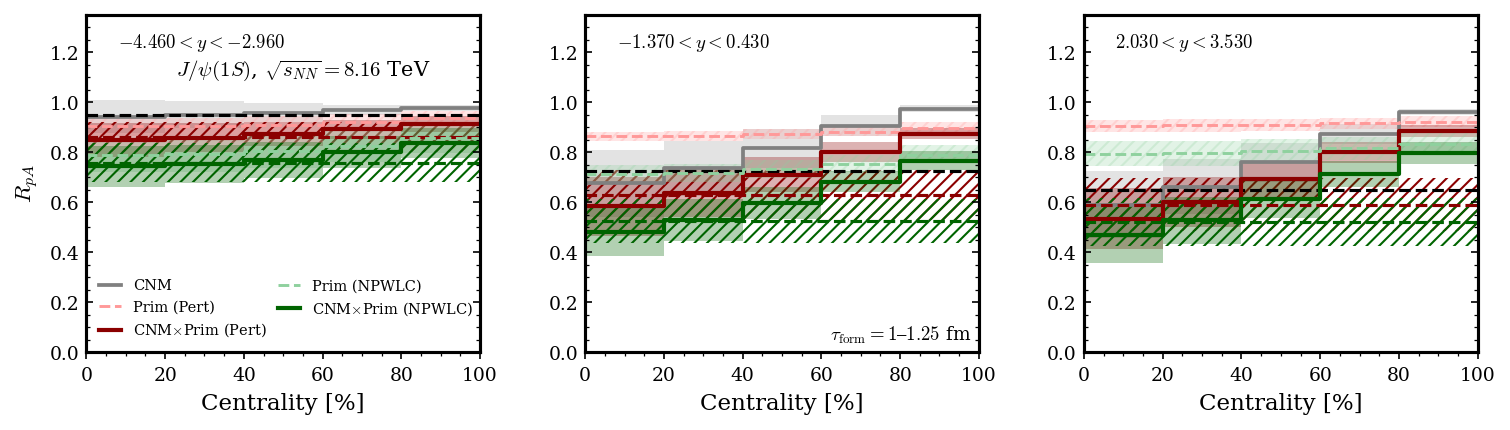

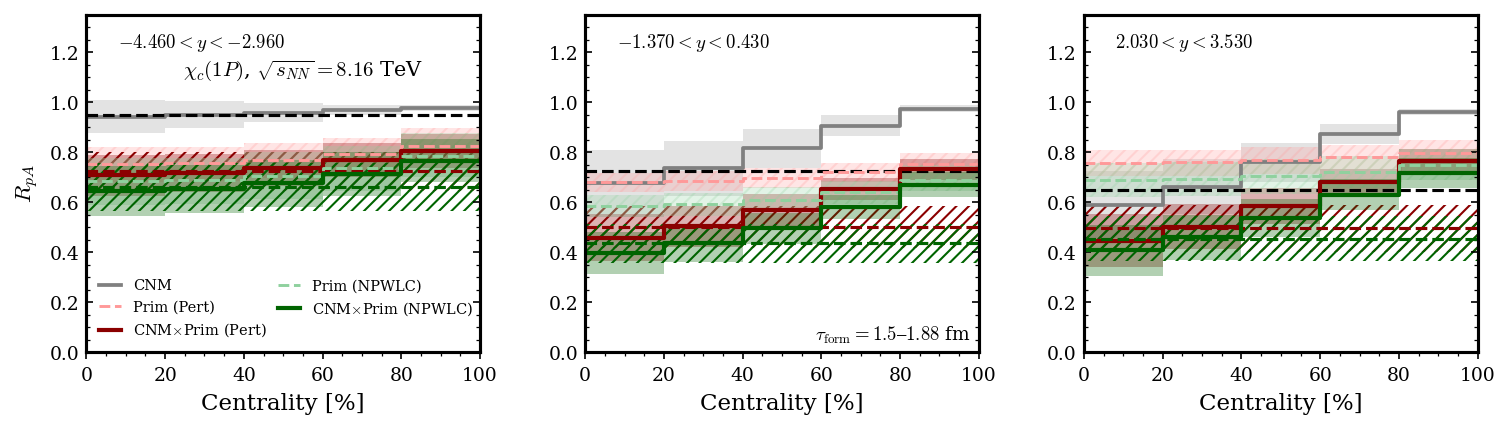

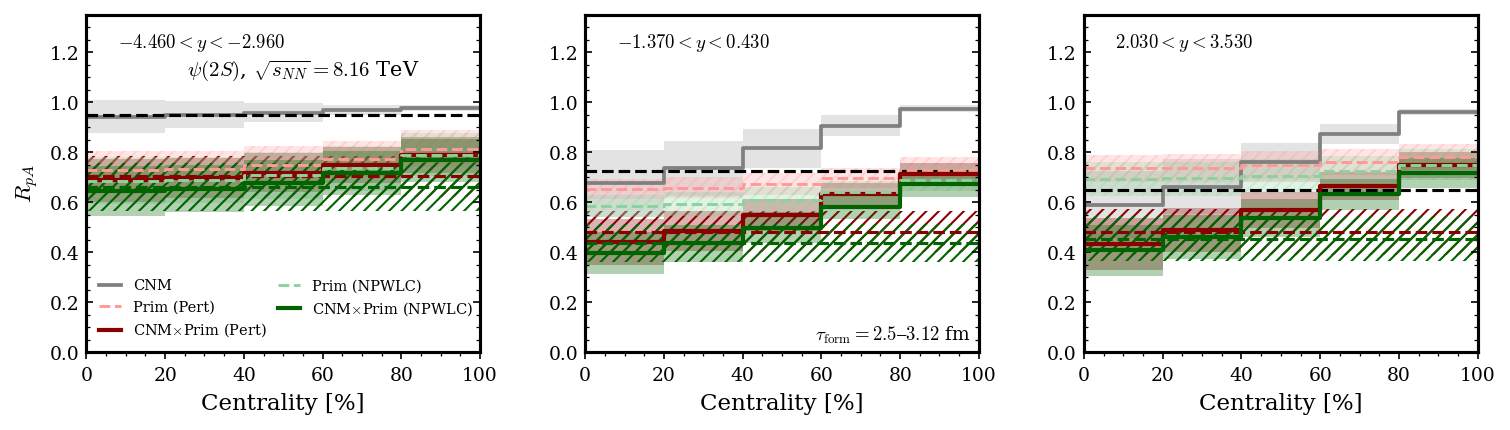

In [ ]:
# ---------- Plot + CSV: R_pA(centrality) ---------------------------

# Minimal switches to show/hide components
SHOW_CNM  = True   # total CNM band
SHOW_PRIM = True   # primordial bands
SHOW_COMB = True   # CNM × primordial

for state in CHARM_STATES:
    # Only keep y-windows that actually have combined results
    ywins = []
    for (y0, y1, yname) in DEFAULT_Y_WINDOWS:
        if yname in combined_cent[state] and yname in cnm_cent_all:
            ywins.append((y0, y1, yname))
    if not ywins:
        continue

    n_pan = len(ywins)
    fig, axes = plt.subplots(
        1, n_pan,
        figsize=(3.4 * n_pan, 3.0),   # slightly narrower, a bit taller
        dpi=DPI,
        sharey=False
    )
    axes = np.atleast_1d(axes)

    csv_rows = []

    for iax, (y0, y1, yname) in enumerate(ywins):
        ax = axes[iax]

        cnm_cent_block = cnm_cent_all[yname]
        Rc_cnm, Rlo_cnm, Rhi_cnm, Rc_MB_cnm, Rlo_MB_cnm, Rhi_MB_cnm = cnm_cent_block["cnm"]

        edges = np.array([CENT_BINS[0][0]] + [b for (_, b) in CENT_BINS], float)
        y_c  = np.concatenate([Rc_cnm,  Rc_cnm[-1:]])
        y_lo = np.concatenate([Rlo_cnm, Rlo_cnm[-1:]])
        y_hi = np.concatenate([Rhi_cnm, Rhi_cnm[-1:]])

        handles, labels = [], []

        # --- CNM band (optional) ---
        if SHOW_CNM:
            ln_cnm, = ax.step(
                edges, y_c, where="post",
                color=COMB_COLORS["cnm"],
                ls=COMB_LS["cnm"], lw=1.8,
                label=COMB_LABEL["cnm"],
            )
            ax.fill_between(
                edges, y_lo, y_hi,
                step="post", color=COMB_COLORS["cnm"],
                alpha=ALPHA_BAND, linewidth=0.0,
            )

            # CNM MB line
            x_mb = np.array([0.0, 100.0])
            ax.hlines(
                Rc_MB_cnm, x_mb[0], x_mb[1],
                colors="k", linestyles="--", linewidth=1.5,
            )

            handles.append(ln_cnm)
            labels.append(COMB_LABEL["cnm"])

            # ----- CSV: CNM slices -----
            for (cent_lo, cent_hi), rc, rlo, rhi in zip(CENT_BINS, Rc_cnm, Rlo_cnm, Rhi_cnm):
                csv_rows.append({
                    "energy": ENERGY,
                    "state": state,
                    "component": "CNM",
                    "prim_model": "",
                    "y_window": yname,
                    "centrality_lo": cent_lo,
                    "centrality_hi": cent_hi,
                    "is_MB": 0,
                    "R": rc, "R_lo": rlo, "R_hi": rhi,
                })
            # CNM MB
            csv_rows.append({
                "energy": ENERGY,
                "state": state,
                "component": "CNM",
                "prim_model": "",
                "y_window": yname,
                "centrality_lo": 0,
                "centrality_hi": 100,
                "is_MB": 1,
                "R": Rc_MB_cnm, "R_lo": Rlo_MB_cnm, "R_hi": Rhi_MB_cnm,
            })
        else:
            # still define x_mb for combined MB bands below
            x_mb = np.array([0.0, 100.0])

        # ---- primordial + combined for each primordial model ----
        prim_key = _cnm_ywindow_to_prim_key(y0, y1, yname)

        for model in MODELS:
            if model not in combined_cent[state][yname]:
                continue
            if model not in prim_cent[prim_key]:
                continue
            if state not in prim_cent[prim_key][model]:
                continue

            cent_mid_cb, Rc_cb, Rlo_cb, Rhi_cb, Rc_MB_cb, Rlo_MB_cb, Rhi_MB_cb = \
                combined_cent[state][yname][model]

            cent_mid_p, Rc_p, Rlo_p, Rhi_p, Rc_MB_p, Rlo_MB_p, Rhi_MB_p = \
                prim_cent[prim_key][model][state]
            cent_mid_p = np.asarray(cent_mid_p, float)
            if not np.allclose(cent_mid_p, cent_mid_cb):
                Rc_p, Rlo_p, Rhi_p = _interp_band_to_grid(
                    cent_mid_p, Rc_p, Rlo_p, Rhi_p, cent_mid_cb
                )

            # --- primordial steps (optional) ---
            if SHOW_PRIM:
                y_p_c  = np.concatenate([Rc_p,  Rc_p[-1:]])
                y_p_lo = np.concatenate([Rlo_p, Rlo_p[-1:]])
                y_p_hi = np.concatenate([Rhi_p, Rhi_p[-1:]])

                ln_p, = ax.step(
                    edges, y_p_c, where="post",
                    color=COMB_COLORS[(model, "prim")],
                    ls=COMB_LS[(model, "prim")], lw=1.4,
                    label=COMB_LABEL[(model, "prim")],
                )
                ax.fill_between(
                    edges, y_p_lo, y_p_hi,
                    step="post", color=COMB_COLORS[(model, "prim")],
                    alpha=0.25, linewidth=0.0,
                    hatch='////',
                )
                handles.append(ln_p); labels.append(COMB_LABEL[(model, "prim")])

                # CSV: primordial slices
                for (cent_lo, cent_hi), rc, rlo, rhi in zip(CENT_BINS, Rc_p, Rlo_p, Rhi_p):
                    csv_rows.append({
                        "energy": ENERGY,
                        "state": state,
                        "component": "primordial",
                        "prim_model": model,
                        "y_window": yname,
                        "centrality_lo": cent_lo,
                        "centrality_hi": cent_hi,
                        "is_MB": 0,
                        "R": rc, "R_lo": rlo, "R_hi": rhi,
                    })
                # CSV: primordial MB
                csv_rows.append({
                    "energy": ENERGY,
                    "state": state,
                    "component": "primordial",
                    "prim_model": model,
                    "y_window": yname,
                    "centrality_lo": 0,
                    "centrality_hi": 100,
                    "is_MB": 1,
                    "R": Rc_MB_p, "R_lo": Rlo_MB_p, "R_hi": Rhi_MB_p,
                })

            # --- combined steps (optional) ---
            if SHOW_COMB:
                y_cb_c  = np.concatenate([Rc_cb,  Rc_cb[-1:]])
                y_cb_lo = np.concatenate([Rlo_cb, Rlo_cb[-1:]])
                y_cb_hi = np.concatenate([Rhi_cb, Rhi_cb[-1:]])

                ln_cb, = ax.step(
                    edges, y_cb_c, where="post",
                    color=COMB_COLORS[(model, "comb")],
                    ls=COMB_LS[(model, "comb")], lw=2.0,
                    label=COMB_LABEL[(model, "comb")],
                )
                ax.fill_between(
                    edges, y_cb_lo, y_cb_hi,
                    step="post", color=COMB_COLORS[(model, "comb")],
                    alpha=0.30, linewidth=0.0,
                )
                handles.append(ln_cb); labels.append(COMB_LABEL[(model, "comb")])

                # hatched MB band for combined
                if np.isfinite(Rc_MB_cb):
                    y_mb_lo = np.array([Rlo_MB_cb, Rlo_MB_cb])
                    y_mb_hi = np.array([Rhi_MB_cb, Rhi_MB_cb])
                    ax.fill_between(
                        x_mb, y_mb_lo, y_mb_hi,
                        color="none", hatch="////",
                        edgecolor=COMB_COLORS[(model, "comb")],
                        linewidth=0.0,
                    )
                    ax.hlines(
                        Rc_MB_cb, x_mb[0], x_mb[1],
                        colors=COMB_COLORS[(model, "comb")],
                        linestyles="--", linewidth=1.5,
                    )

                    # CSV: combined MB
                    csv_rows.append({
                        "energy": ENERGY,
                        "state": state,
                        "component": "CNM_x_prim",
                        "prim_model": model,
                        "y_window": yname,
                        "centrality_lo": 0,
                        "centrality_hi": 100,
                        "is_MB": 1,
                        "R": Rc_MB_cb, "R_lo": Rlo_MB_cb, "R_hi": Rhi_MB_cb,
                    })

                # CSV: combined slices
                for (cent_lo, cent_hi), rc, rlo, rhi in zip(CENT_BINS, Rc_cb, Rlo_cb, Rhi_cb):
                    csv_rows.append({
                        "energy": ENERGY,
                        "state": state,
                        "component": "CNM_x_prim",
                        "prim_model": model,
                        "y_window": yname,
                        "centrality_lo": cent_lo,
                        "centrality_hi": cent_hi,
                        "is_MB": 0,
                        "R": rc, "R_lo": rlo, "R_hi": rhi,
                    })

        # ----- axes cosmetics -----
        ax.minorticks_on()
        ax.tick_params(axis='y', which='both', direction='in', right=True)
        ax.tick_params(axis='x', which='both', direction='out', top=False, bottom=True)
        ax.set_yticks(np.arange(0.0, 1.41, 0.2))
        ax.tick_params(axis='both', which='major', labelsize=9)
        ax.tick_params(axis='both', which='minor', labelsize=9)

        ax.set_xlim(0.0, 100.0)
        ax.set_ylim(0.0, 1.35)
        ax.set_xlabel("Centrality [%]", fontsize=11)
        if iax == 0:
            ax.set_ylabel(r"$R_{pA}$", fontsize=11)
        ax.grid(False)

        # --- y-window label ---
        label_ywin = rf"${y0:.3f} < y < {y1:.3f}$"
        ax.text(
            0.08, 0.95, label_ywin,
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=9,
            bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"),
        )

        # legend: only in first panel, with two columns and smaller font
        if iax == 0 and handles:
            uniq = {}
            for h, l in zip(handles, labels):
                uniq[l] = h
            ax.legend(
                list(uniq.values()), list(uniq.keys()),
                loc="lower left",
                frameon=False,
                fontsize=7,
                ncol=2,
                columnspacing=0.8,
                handlelength=1.5,
            )

    # --- state + energy note (no global title) ---
    tau_lo, tau_hi = TAUFORM[state]
    note_line1 = rf"{CHARM_STATE_LABELS[state]}, $\sqrt{{s_{{NN}}}}={float(ENERGY):.2f}$ TeV"
    axes[0].text(
        0.550, 0.80, note_line1,
        transform=axes[0].transAxes,
        ha="center", va="bottom",
        fontsize=10,
        # bbox=dict(facecolor="white", alpha=0.80, edgecolor="none"),
    )
    note_line2 = rf"$\tau_{{\rm form}}={tau_lo:.3g}\text{{–}}{tau_hi:.3g}$ fm"
    if len(axes) > 1:
        ax_tau = axes[1]
    else:
        ax_tau = axes[0]
    ax_tau.text(
        0.98, 0.02, note_line2,
        transform=ax_tau.transAxes,
        ha="right", va="bottom",
        fontsize=9,
        # bbox=dict(facecolor="white", alpha=0.80, edgecolor="none"),
    )

    fig.tight_layout()
    if SAVE_PDF:
        fig.savefig(
            OUTDIR_CNM / f"RpA_CNM_prim_combined_vs_centrality_{state}_{ENERGY.replace('.','p')}TeV.pdf",
            bbox_inches="tight",
        )

    if SAVE_CSV and csv_rows:
        df_out = pd.DataFrame(csv_rows)
        df_out.to_csv(
            OUTDIR_CNM / f"RpA_CNM_prim_combined_vs_centrality_{state}_{ENERGY.replace('.','p')}TeV.csv",
            index=False,
        )